# Assignment 1

## DATA LOAD

In [140]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pypsa
import logging

pd.options.future.infer_string = False
pd.options.mode.string_storage = "python"
logging.getLogger("linopy").setLevel(logging.ERROR)
logging.getLogger("pypsa").setLevel(logging.ERROR)

# Capacity factor year can be chosen to be different
capacity_factor_year = 2017

def hourly_climatology(df):
    df = df[~((df.utc_time.dt.month == 2) & (df.utc_time.dt.day == 29))]
    df["month"] = df["utc_time"].dt.month
    df["day"] = df["utc_time"].dt.day
    df["hour"] = df["utc_time"].dt.hour
    
    result = (
        df.groupby(["month","day","hour"])["cf"]
        .mean()
        .reset_index()
    )
    result["timestamp"] = pd.to_datetime(dict(year=2017, month=result["month"], day=result["day"], hour=result["hour"]))

    result = result.sort_values("timestamp").reset_index(drop=True)

    # Create formatted column
    result["datetime"] = result["timestamp"].dt.strftime("%d/%m %H:%M")

    return result


def load_base_year_data(cf_year):
    """
    If cf_year = None then use 10 year average capacity factor data
    If cf_year is given then show the actual year
    """
    demand = pd.read_csv("../data/denmark_demand.csv", index_col=0)
    if cf_year is None:
        offshore_wind_cf = pd.read_csv("../data/averaged_offshore_wind_capacity_factor_denmark_hourly.csv", index_col=0)
        onshore_wind_cf = pd.read_csv("../data/averaged_onshore_wind_capacity_factor_denmark_hourly.csv", index_col=0)
        pv_cf = pd.read_csv("../data/averaged_pv_capacity_factor_denmark_hourly.csv", index_col=0)
        demand = pd.read_csv("../data/denmark_demand.csv", index_col=0)

        pv = pv_cf.rename(columns={"cf": "pv_cf"})
        onshore = onshore_wind_cf.rename(columns={"cf": "onshore_cf"})
        offshore = offshore_wind_cf.rename(columns={"cf": "offshore_cf"})

        work_df = pd.concat([pv, onshore, offshore, demand], axis=1)
        work_df.index = pd.to_datetime(
            "2015/" + work_df.index.astype(str),
            format="%Y/%d/%m %H:%M"
        )

        work_df.index = work_df.index.strftime("%d/%m/%Y %H:%M")

        work_df = work_df.rename(columns={"demand": "demand_mw"})
        return work_df
    else:

        offshore_wind_cf_df = pd.read_csv("../data/offshore_wind_capacity_factor_raw.csv",delimiter=";")
        onshore_wind_cf_df = pd.read_csv("../data/onshore_wind_capacity_factor_raw.csv", delimiter=";")
        pv_cf_df = pd.read_csv("../data/pv_capacity_factor_raw.csv", delimiter=";")

        # Convert ISO8601 to datetime
        offshore_wind_cf_df["utc_time"] = pd.to_datetime(offshore_wind_cf_df["utc_time"], utc=True, errors="raise")
        onshore_wind_cf_df["utc_time"] = pd.to_datetime(onshore_wind_cf_df["utc_time"], utc=True, errors="raise")
        pv_cf_df["utc_time"] = pd.to_datetime(pv_cf_df["utc_time"], utc=True, errors="raise")

        # Keep only time and Denmark
        df_pv = pv_cf_df[["utc_time", "DNK"]]
        df_onshore_wind = onshore_wind_cf_df[["utc_time", "DNK"]]
        df_offshore_wind = offshore_wind_cf_df[["utc_time", "DNK"]]

        # Filter out the exact year
        df_pv = df_pv[df_pv["utc_time"].dt.year == cf_year]
        df_onshore_wind = df_onshore_wind[df_onshore_wind["utc_time"].dt.year == cf_year]
        df_offshore_wind = df_offshore_wind[df_offshore_wind["utc_time"].dt.year == cf_year]

        # Rename columns
        df_pv = df_pv.rename(columns={"DNK": "cf"})
        df_onshore_wind = df_onshore_wind.rename(columns={"DNK": "cf"})
        df_offshore_wind = df_offshore_wind.rename(columns={"DNK": "cf"})
        
        # Remove year from capacity factor dataframes
        df_pv = hourly_climatology(df_pv)
        df_onshore_wind = hourly_climatology(df_onshore_wind)
        df_offshore_wind = hourly_climatology(df_offshore_wind)

        df_pv = df_pv[["datetime", "cf"]]
        df_onshore_wind = df_onshore_wind[["datetime", "cf"]]
        df_offshore_wind = df_offshore_wind[["datetime", "cf"]]

        # Rename columns
        df_pv = df_pv.rename(columns={"cf": "pv_cf"})
        df_onshore_wind = df_onshore_wind.rename(columns={"cf": "onshore_cf"})
        df_offshore_wind = df_offshore_wind.rename(columns={"cf": "offshore_cf"})

        # Set index
        df_pv = df_pv.set_index("datetime")
        df_onshore_wind = df_onshore_wind.set_index("datetime")
        df_offshore_wind = df_offshore_wind.set_index("datetime")

        # Concat the dataframes
        work_df = pd.concat([df_pv, df_onshore_wind, df_offshore_wind, demand], axis=1)
        work_df.index = pd.to_datetime(
            str(cf_year) + "/" + work_df.index.astype(str),
            format="%Y/%d/%m %H:%M"
        )

        work_df.index = work_df.index.strftime("%d/%m/%Y %H:%M")

        work_df = work_df.rename(columns={"demand": "demand_mw"})
        return work_df
        
work_df = load_base_year_data(capacity_factor_year)
work_df.index = pd.DatetimeIndex(
    pd.to_datetime(work_df.index, format="%d/%m/%Y %H:%M")
)


In [141]:
color_map = {
    "PV": "gold",                 # yellow
    "OnshoreWind": "skyblue",     # light blue
    "OffshoreWind": "deepskyblue",
    "Nuclear": "pink",
    "BiomassCHP": "green",
    "Coal": "gray",
    "Hydro generation": "blue",
    "OCGT": "lightgray",
    "CCGT": "darkred",
    "Oil": "teal",
    "BESS discharge": "orange",
    "BESS charge": "navy"
}

In [142]:
# Technology lifetimes
onshore_wind_lifetime = 30 # years
offshore_wind_lifetime = 30 # years
pv_lifetime = 35 # years
ccgt_lifetime = 25 # years
ocgt_lifetime = 25 # years
biomass_chp_lifetime = 25 # years
coal_lifetime = 45 # years
oil_lifetime = 32 # years

# CAPEX
onshore_wind_capex = 1160000 # EUR/MW
offshore_wind_capex = 2500000 # EUR/MW
pv_capex = 500000 # EUR/MW
ccgt_capex = 900000 # EUR/MW
ocgt_capex = 600000 # EUR/MW
biomass_chp_capex = 5000000 # EUR/MW
coal_capex = 2750000 # EUR/MW
oil_capex = 900000 # EUR/MW

# Annualised capital costs
annualised_offshore_wind_capex = offshore_wind_capex / offshore_wind_lifetime # EUR/MW/year
annualised_onshore_wind_capex = onshore_wind_capex / onshore_wind_lifetime # EUR/MW/year
annualised_pv_capex = pv_capex / pv_lifetime # EUR/MW/year
annualised_ccgt_capex = ccgt_capex / ccgt_lifetime # EUR/MW/year
annualised_ocgt_capex = ocgt_capex / ocgt_lifetime # EUR/MW/year
annualised_chp_capex = biomass_chp_capex / biomass_chp_lifetime # EUR/MW/year
annualised_coal_capex = coal_capex / coal_lifetime # EUR/MW/year
annualised_oil_capex = oil_capex / oil_lifetime # EUR/MW/year


# Annual OPEX costs
offshore_wind_opex = 40000 # EUR/MW/year
onshore_wind_opex = 17000 # EUR/MW/year
pv_opex = 10500 # EUR/MW/year
ccgt_opex = 30500 # EUR/MW/year
ocgt_opex = 20000 # EUR/MW/year
chp_opex = 150000 # EUR/MW/year
coal_opex = 45 * 1000 # EUR/MW/year
oil_opex = 35 * 1000 # EUR/MW/year

# Efficiencies of generators
ccgt_efficiency = 0.57
ocgt_efficiency = 0.4
chp_efficiency = 0.25
coal_efficiency = 0.38
oil_efficiency = 0.3

# Input costs
gas_price = 30 # €/MWh
chp_input_price = 25 # €/MWh
coal_fuel_price = 27.5 # €/MWh
oil_fuel_price = 95 # €/MWh

# Setting up marginal generation costs
onshore_wind_marginal_cost = 4 # EUR/MWh
offshore_wind_marginal_cost = 2 # EUR/MWh
pv_marginal_cost = 0 # EUR/MWh
ccgt_marginal_cost = 4.5 + gas_price / ccgt_efficiency # EUR/MWh
ocgt_marginal_cost =  4.5 + gas_price / ocgt_efficiency # EUR/MWh
chp_marginal_cost = 15 + chp_input_price / chp_efficiency # EUR/MWh
coal_marginal_cost = 4 + coal_fuel_price / coal_efficiency # EUR/MWh
oil_marginal_cost = 5 + oil_fuel_price / oil_efficiency # EUR/MWh



## PART A


### PyPsa model setup

In [143]:
n = pypsa.Network()

# Set time snapshots
n.set_snapshots(work_df.index)

# Carriers
n.add("Carrier","OnshoreWind",co2_emissions=0,nice_name="Onshore wind")
n.add("Carrier","OffshoreWind",co2_emissions=0,nice_name="Offshore wind")
n.add("Carrier","PV",co2_emissions=0,nice_name="PV")
n.add("Carrier","AC",co2_emissions=0)
n.add("Carrier","BiomassCHP",co2_emissions=0,nice_name="Biomass CHP")
n.add("Carrier","CCGT",co2_emissions=0,nice_name="CCGT")
n.add("Carrier","OCGT",co2_emissions=0,nice_name="OCGT")
n.add("Carrier","Coal",co2_emissions=0,nice_name="Coal")
n.add("Carrier","Oil",co2_emissions=0,nice_name="Oil")

# Buses
n.add("Bus","DK",carrier="AC",)

# Load
n.add("Load","DKLoad",bus="DK",p_set=work_df["demand_mw"].to_numpy())

# Generators
n.add("Generator","DKOffshoreWind",bus="DK",carrier="OffshoreWind",p_nom_extendable=True,p_nom_min=2650,p_nom=2650,p_max_pu = work_df["offshore_cf"].to_numpy(),marginal_cost=float(offshore_wind_marginal_cost),capital_cost=float(annualised_offshore_wind_capex + offshore_wind_opex))
n.add("Generator","DKOnshoreWind",bus="DK",carrier="OnshoreWind",p_nom_extendable=True,p_nom_min=4860,p_nom=4860,p_max_pu = work_df["onshore_cf"].to_numpy(),marginal_cost=float(onshore_wind_marginal_cost),capital_cost=float(annualised_onshore_wind_capex+ onshore_wind_opex))
n.add("Generator","DKPV",bus="DK",carrier="PV",p_nom_extendable=True,p_nom_min=4800,p_nom=4800,p_max_pu = work_df["pv_cf"].to_numpy(),marginal_cost=float(pv_marginal_cost),capital_cost=float(annualised_pv_capex + pv_opex))
n.add("Generator","DKBiomassCHP",bus="DK",carrier="BiomassCHP",p_nom_min=2000,p_nom=2000,p_nom_extendable=True,marginal_cost=float(chp_marginal_cost),capital_cost=float(annualised_chp_capex + chp_opex))
n.add("Generator","DKCCGT",bus="DK",carrier="CCGT",p_nom_extendable=True,p_nom_min=1750,p_nom=1750,marginal_cost=float(ccgt_marginal_cost),capital_cost=float(annualised_ccgt_capex + ccgt_opex))
n.add("Generator","DKOCGT",bus="DK",carrier="OCGT",p_nom_extendable=True,p_nom_min=750,p_nom=750,marginal_cost=float(ocgt_marginal_cost),capital_cost=float(annualised_ocgt_capex + ocgt_opex))
n.add("Generator","DKCoal",bus="DK",carrier="Coal",p_nom_extendable=True,p_nom_min=650,p_nom=650,marginal_cost=coal_marginal_cost,capital_cost=annualised_coal_capex + coal_opex)
n.add("Generator","DKOil",bus="DK",carrier="Oil",p_nom_extendable=True,p_nom_min=300,p_nom=300,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

### Gurobi

In [144]:
n.optimize(
    solver_name="gurobi",
    solver_options={"OutputFlag": 0}
)

Writing continuous variables.: 100%|██████████| 3/3 [00:00<00:00, 165.81it/s]

Set parameter Username



INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2815072


INFO:gurobipy:Set parameter LicenseID to value 2815072


...

Reading time = 0.20 seconds


INFO:gurobipy:Reading time = 0.20 seconds


obj: 148928 rows, 70089 columns, 275965 nonzeros


INFO:gurobipy:obj: 148928 rows, 70089 columns, 275965 nonzeros


('ok', 'optimal')

### Results

#### Winter week

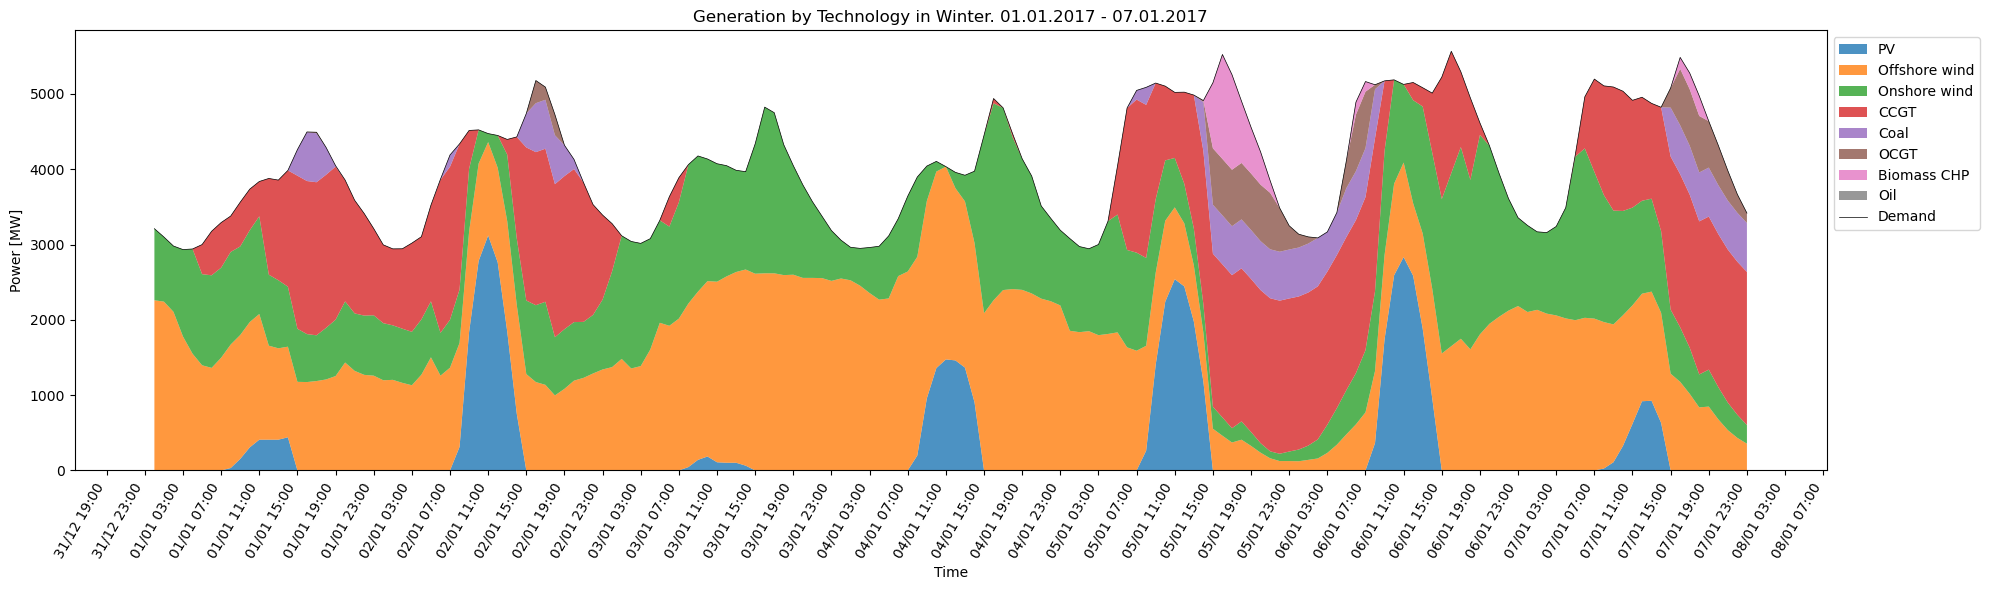

In [145]:
# Date range winter week
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-01-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-01-07 23:00:00")
else:
    start_date = pd.Timestamp("2015-01-01 00:00:00")
    end_date   = pd.Timestamp("2015-01-07 23:00:00")

# --- Dispatch ---
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Marginal cost per technology
cost_df = n.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n.carriers.nice_name)

# If multiple generators per tech → take mean (or min)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()

# Sort technologies (cheapest first)
tech_order = cost_by_tech.sort_values().index.tolist()

# Reorder columns
dispatch_nice = dispatch_nice[tech_order]

# --- Slice time ---
dispatch_plot = dispatch_nice.loc[start_date:end_date]
demand_plot = work_df.loc[start_date:end_date, "demand_mw"]

# Ensure datetime index
dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)

# --- Plot ---
fig, ax = plt.subplots(figsize=(20, 6))

x = dispatch_plot.index
y = [dispatch_plot[col].to_numpy() for col in dispatch_plot.columns]

ax.stackplot(x, y, labels=dispatch_plot.columns, alpha=0.8)

ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    linewidth=0.5,
    color="black",
    label="Demand"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")

if capacity_factor_year is not None:
    ax.set_title(
    f"Generation by Technology in Winter. "
    f"{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
)
else:
    ax.set_title("Generation by Technology in Winter. Capacity Factors 10 year average 2007 - 2017.")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

#### Summer week

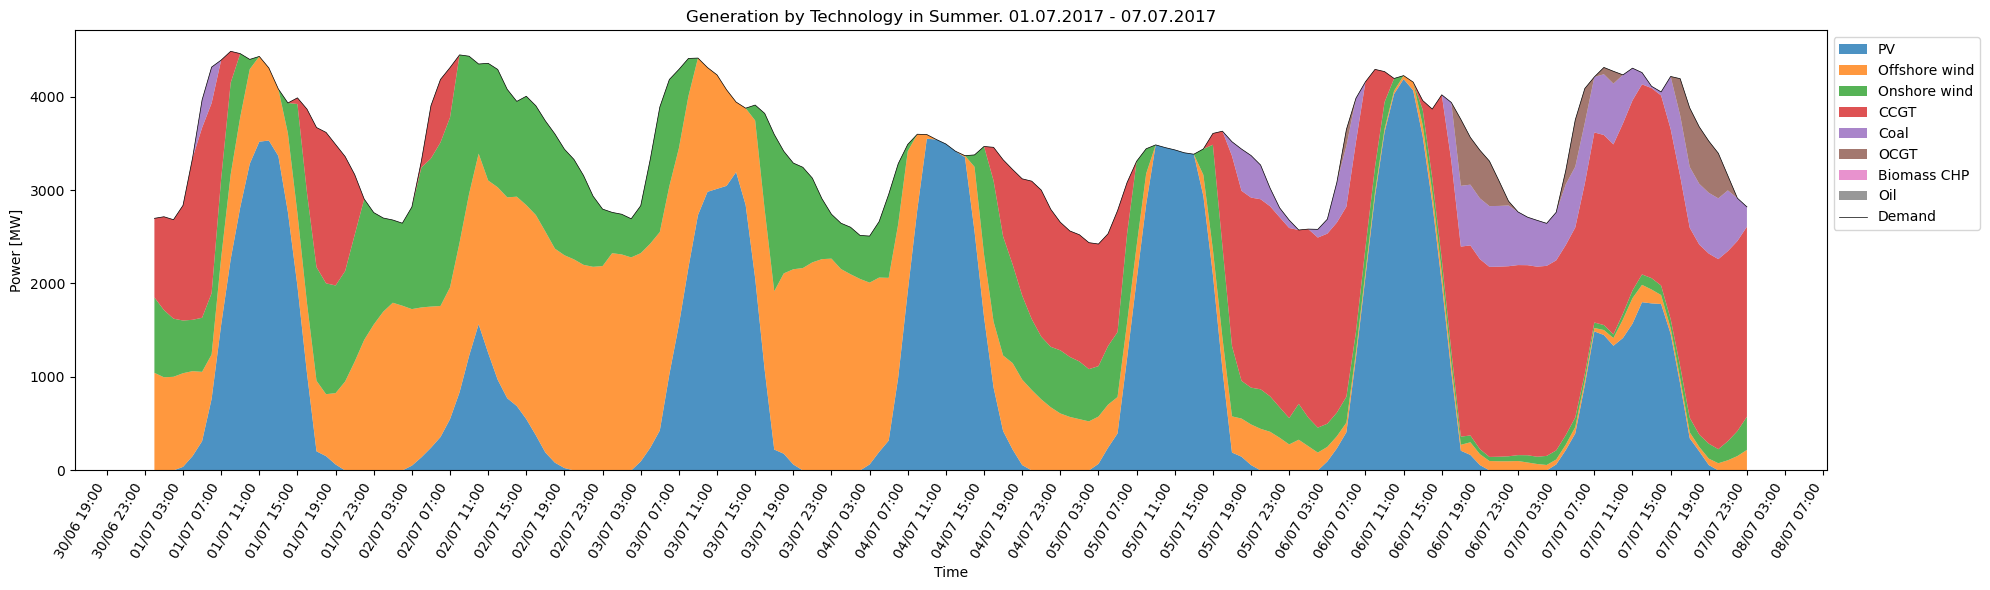

In [146]:
# Date range summer week
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-07-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-07-07 23:00:00")
else:
    start_date = pd.Timestamp("2015-07-01 00:00:00")
    end_date   = pd.Timestamp("2015-07-07 23:00:00")

# --- Dispatch ---
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Marginal cost per technology
cost_df = n.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n.carriers.nice_name)

# If multiple generators per tech +> take mean (or min)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()

# Sort technologies (cheapest first)
tech_order = cost_by_tech.sort_values().index.tolist()

# Reorder columns
dispatch_nice = dispatch_nice[tech_order]

# --- Slice time ---
dispatch_plot = dispatch_nice.loc[start_date:end_date]
demand_plot = work_df.loc[start_date:end_date, "demand_mw"]

# Ensure datetime index
dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)

# --- Plot ---
fig, ax = plt.subplots(figsize=(20, 6))

x = dispatch_plot.index
y = [dispatch_plot[col].to_numpy() for col in dispatch_plot.columns]

ax.stackplot(x, y, labels=dispatch_plot.columns, alpha=0.8)

ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    linewidth=0.5,
    color="black",
    label="Demand"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")

if capacity_factor_year is not None:
    ax.set_title(
    f"Generation by Technology in Summer. "
    f"{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
)
else:
    ax.set_title("Generation by Technology in Summer. Capacity Factors 10 year average 2007 - 2017.")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

#### Optimal capacities

In [147]:
capacity = n.generators[["carrier", "p_nom_opt"]].copy()

# Map to nice names
capacity["Technology"] = capacity["carrier"].map(n.carriers.nice_name)

# Aggregate by technology
capacity_table = (
    capacity.groupby("Technology")["p_nom_opt"]
    .sum()
    .sort_values(ascending=False)
    .round(1)
)

if capacity_factor_year is not None:
    print(f"Year used for simulation: {capacity_factor_year}")
else:
    print("10 year average (2007 - 2017) was used for capacity factors")
print(capacity_table)

Year used for simulation: 2017
Technology
PV               6382.2
Onshore wind     4860.0
Offshore wind    2650.0
CCGT             2033.1
Biomass CHP      2000.0
OCGT              750.0
Coal              650.0
Oil               300.0
Name: p_nom_opt, dtype: float64


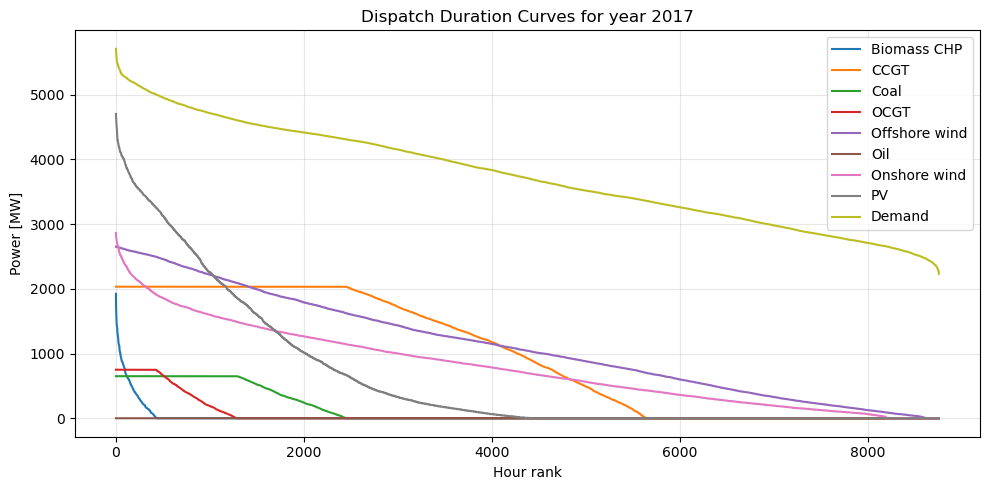

In [148]:
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

dispatch_nice["Demand"] = work_df["demand_mw"]

duration_df = pd.DataFrame({
    col: dispatch_nice[col].sort_values(ascending=False).values
    for col in dispatch_nice.columns
})

fig, ax = plt.subplots(figsize=(10, 5))

duration_df.plot(ax=ax)

ax.set_title(f"Dispatch Duration Curves for year {capacity_factor_year}")
ax.set_xlabel("Hour rank")
ax.set_ylabel("Power [MW]")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Annual electricity mix

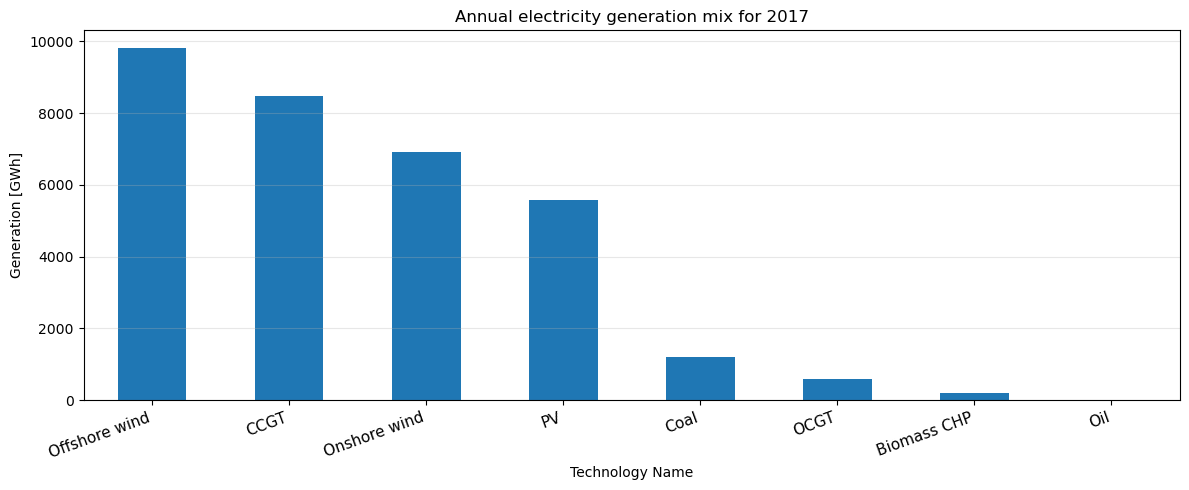

In [149]:
# Annual generation by technology [MWh]
annual_generation = dispatch_nice.drop(columns="Demand", errors="ignore").sum(axis=0)

annual_generation_df = annual_generation.to_frame(name="generation_mwh")
annual_generation_df["generation_gwh"] = annual_generation_df["generation_mwh"] / 1000

annual_generation_df["share"] = (
    annual_generation_df["generation_mwh"] /
    annual_generation_df["generation_mwh"].sum()
)

annual_generation_df["share_percent"] = 100 * annual_generation_df["share"]

annual_generation_df.sort_values("generation_mwh", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))  # wider figure

annual_generation_df["generation_gwh"] \
    .sort_values(ascending=False) \
    .plot.bar(ax=ax)

# Labels and title
ax.set_ylabel("Generation [GWh]")
ax.set_xlabel("Technology Name")  # X label added
ax.set_title(f"Annual electricity generation mix for {capacity_factor_year}")

# Rotate x labels and increase font size
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=11)

# Grid
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## PART B

### Results of yearly simulations

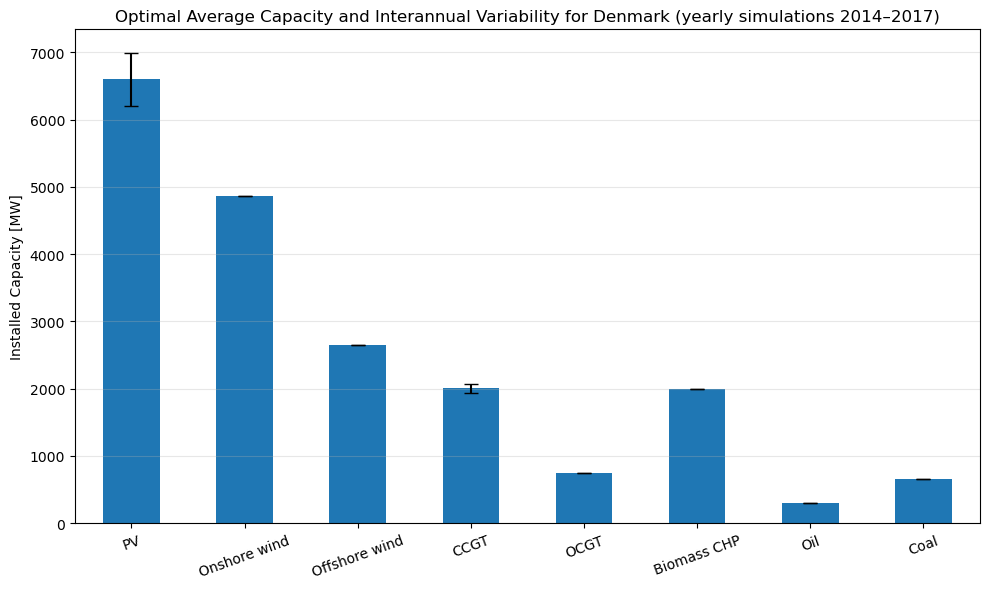

In [150]:
# Results from simulation
capacity_by_year = pd.DataFrame({
    2014: {
        "PV": 6597.2,
        "Onshore wind": 4860.0,
        "Offshore wind": 2650.0,
        "CCGT": 1952.7,
        "OCGT": 750.0,
        "Biomass CHP": 2000.0,
        "Oil": 300.0,
        "Coal": 650.0,
    },
    2015: {
        "PV": 6272.9,
        "Onshore wind": 4860.0,
        "Offshore wind": 2650.0,
        "CCGT": 1938.1,
        "OCGT": 750.0,
        "Biomass CHP": 2000.0,
        "Oil": 300.0,
        "Coal": 650.0,
    },
    2016: {
        "PV": 7153.1,
        "Onshore wind": 4860.0,
        "Offshore wind": 2650.0,
        "CCGT": 2084.2,
        "OCGT": 750.0,
        "Biomass CHP": 2000.0,
        "Oil": 300.0,
        "Coal": 650.0,
    },
    2017: {
        "PV": 6382.2,
        "Onshore wind": 4860.0,
        "Offshore wind": 2650.0,
        "CCGT": 2033.1,
        "OCGT": 750.0,
        "Biomass CHP": 2000.0,
        "Oil": 300.0,
        "Coal": 650.0,
    },
}).T

mean_capacity = capacity_by_year.mean()
std_capacity = capacity_by_year.std()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

mean_capacity.plot.bar(
    yerr=std_capacity,
    ax=ax,
    capsize=5
)

ax.set_ylabel("Installed Capacity [MW]")
ax.set_title("Optimal Average Capacity and Interannual Variability for Denmark (yearly simulations 2014–2017)")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## PART C

### New technologies integration

In [151]:
# Add battery variables
battery_lifetime = 17

# Battery CAPEX
battery_capex = 450000 # EUR/MW

# Annualised capital costs
annualised_battery_inverter_capex = battery_capex / battery_lifetime # EUR/MW/year
annualised_battery_energy_capex = 0.5 # EUR/MWh/year

# Annual OPEX costs
battery_opex = 10000 # EUR/MW/year

# Battery energy-to-power ratio
battery_hours = 2

# Efficiencies
battery_inverter_efficiency = 0.96

### PyPsa model setup

In [152]:
n = pypsa.Network()

# Set time snapshots
n.set_snapshots(work_df.index)

# Carriers
n.add("Carrier","OnshoreWind",co2_emissions=0,nice_name="Onshore wind")
n.add("Carrier","OffshoreWind",co2_emissions=0,nice_name="Offshore wind")
n.add("Carrier","PV",co2_emissions=0,nice_name="PV")
n.add("Carrier","AC",co2_emissions=0)
n.add("Carrier","BiomassCHP",co2_emissions=0,nice_name="Biomass CHP")
n.add("Carrier","CCGT",co2_emissions=0,nice_name="CCGT")
n.add("Carrier","OCGT",co2_emissions=0,nice_name="OCGT")
n.add("Carrier","Coal",co2_emissions=0,nice_name="Coal")
n.add("Carrier","Oil",co2_emissions=0,nice_name="Oil")
n.add("Carrier","BESS",co2_emissions=0,nice_name="BESS")

# Buses
n.add("Bus","DK",carrier="AC",)

# Load
n.add("Load","DKLoad",bus="DK",p_set=work_df["demand_mw"].to_numpy())

#Generators
n.add("Generator","DKOffshoreWind",bus="DK",carrier="OffshoreWind",p_nom_extendable=True,p_nom_min=2650,p_nom=2650,p_max_pu = work_df["offshore_cf"].to_numpy(),marginal_cost=float(offshore_wind_marginal_cost),capital_cost=float(annualised_offshore_wind_capex + offshore_wind_opex),)
n.add("Generator","DKOnshoreWind",bus="DK",carrier="OnshoreWind",p_nom_extendable=True,p_nom_min=4860,p_nom=4860,p_max_pu = work_df["onshore_cf"].to_numpy(),marginal_cost=float(onshore_wind_marginal_cost),capital_cost=float(annualised_onshore_wind_capex + onshore_wind_opex),)
n.add("Generator","DKPV",bus="DK",carrier="PV",p_nom_extendable=True,p_nom_min=4800,p_nom=4800,p_max_pu = work_df["pv_cf"].to_numpy(),marginal_cost=float(pv_marginal_cost),capital_cost=float(annualised_pv_capex + pv_opex),)
n.add("Generator","DKBiomassCHP",bus="DK",carrier="BiomassCHP",p_nom_extendable=True,p_nom_min=2000,p_nom=2000,marginal_cost=float(chp_marginal_cost),capital_cost=float(annualised_chp_capex + chp_opex),)
n.add("Generator","DKCCGT",bus="DK",carrier="CCGT",p_nom_extendable=True,p_nom_min=1750,p_nom=1750,marginal_cost=float(ccgt_marginal_cost),capital_cost=float(annualised_ccgt_capex + ccgt_opex),)
n.add("Generator","DKOCGT",bus="DK",carrier="OCGT",p_nom_extendable=True,p_nom_min=750,p_nom=750,marginal_cost=float(ocgt_marginal_cost),capital_cost=float(annualised_ocgt_capex + ocgt_opex),)
n.add("Generator","DKCoal",bus="DK",carrier="Coal",p_nom_extendable=True,p_nom_min=650,p_nom=650,marginal_cost=coal_marginal_cost,capital_cost=annualised_coal_capex + coal_opex,)
n.add("Generator","DKOil",bus="DK",carrier="Oil",p_nom_extendable=True,p_nom_min=300,p_nom=300,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex,)

# Storage Units
battery_total_annualised_capex = annualised_battery_inverter_capex + battery_opex
n.add("StorageUnit","DKBESS",bus="DK",carrier="BESS",p_nom_extendable=True,p_nom_min=100,p_nom=100,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)

### Gurobi

In [153]:
n.optimize(
    solver_name="gurobi",
    solver_options={"OutputFlag": 0}
)

Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 183.97it/s]

Set parameter Username



INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2815072


INFO:gurobipy:Set parameter LicenseID to value 2815072


...

Reading time = 0.27 seconds


INFO:gurobipy:Reading time = 0.27 seconds


obj: 210249 rows, 96370 columns, 407366 nonzeros


INFO:gurobipy:obj: 210249 rows, 96370 columns, 407366 nonzeros


('ok', 'optimal')

### Results

#### Winter week

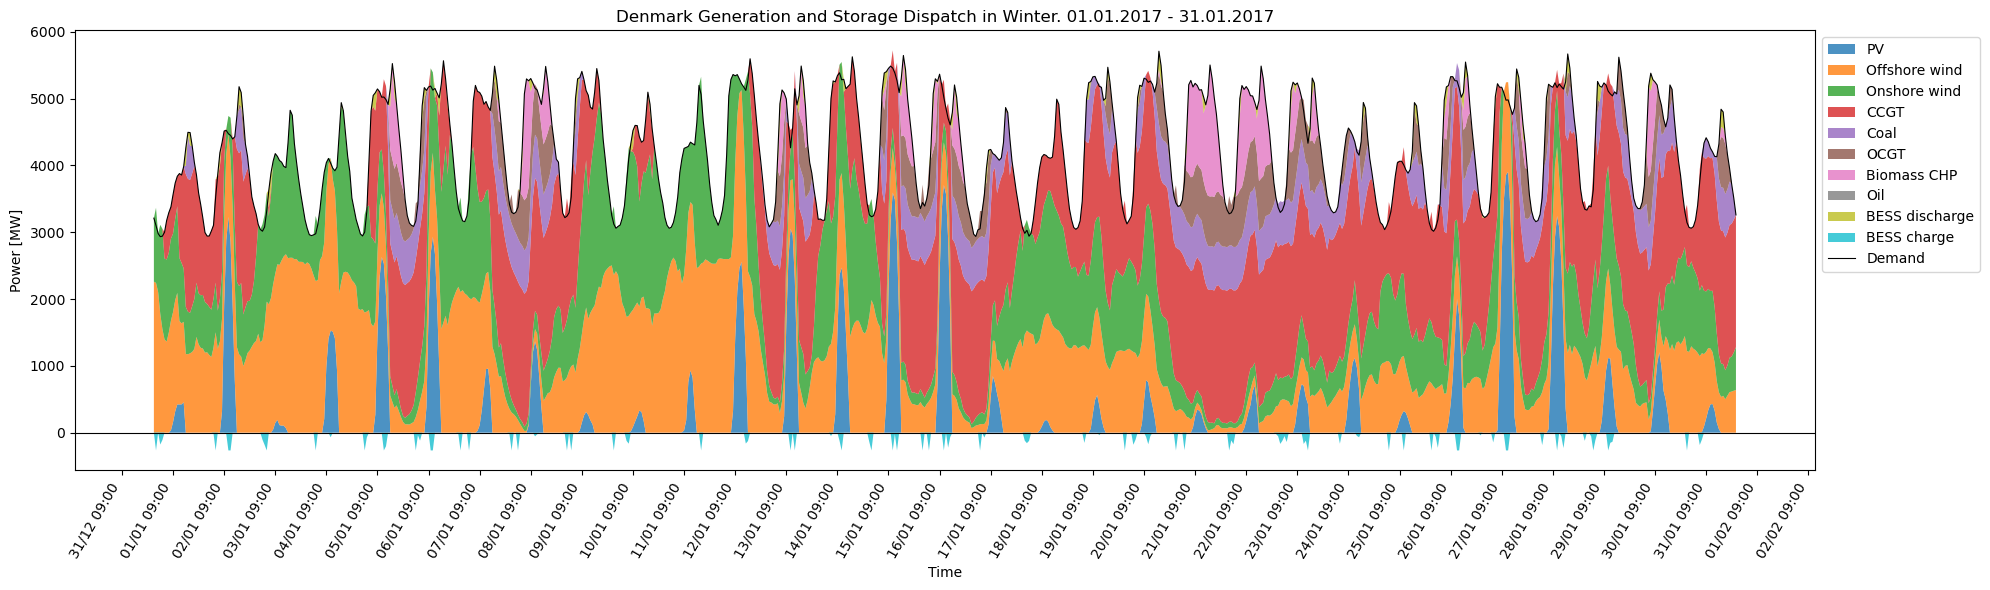

In [154]:
import numpy as np
# Date range winter week
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-01-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-01-31 23:00:00")
else:
    start_date = pd.Timestamp("2015-01-01 00:00:00")
    end_date   = pd.Timestamp("2015-01-31 23:00:00")

# ----------------------------
# GENERATORS
# ----------------------------
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)
dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Marginal cost ordering for generators
cost_df = n.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n.carriers.nice_name)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()
tech_order = cost_by_tech.sort_values().index.tolist()

dispatch_nice = dispatch_nice[tech_order]

# ----------------------------
# STORAGE UNITS
# ----------------------------
# Positive = discharge, negative = charge
storage_p = n.storage_units_t.p.copy()

if not storage_p.empty:
    storage_nice_map = n.storage_units.carrier.map(n.carriers.nice_name).to_dict()

    storage_nice = storage_p.rename(
        columns=lambda s: storage_nice_map.get(s, s)
    )
    storage_nice = storage_nice.T.groupby(level=0).sum().T

    storage_discharge = storage_nice.clip(lower=0)
    storage_charge = storage_nice.clip(upper=0)
else:
    storage_discharge = pd.DataFrame(index=dispatch_nice.index)
    storage_charge = pd.DataFrame(index=dispatch_nice.index)

# ----------------------------
# SLICE TIME
# ----------------------------
dispatch_plot = dispatch_nice.loc[start_date:end_date].copy()
demand_plot = work_df.loc[start_date:end_date, "demand_mw"].copy()
storage_discharge_plot = storage_discharge.loc[start_date:end_date].copy()
storage_charge_plot = storage_charge.loc[start_date:end_date].copy()

dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)
storage_discharge_plot.index = pd.to_datetime(storage_discharge_plot.index)
storage_charge_plot.index = pd.to_datetime(storage_charge_plot.index)

# ----------------------------
# PLOT
# ----------------------------
fig, ax = plt.subplots(figsize=(20, 6))
x = dispatch_plot.index

# Positive stack: generators first
pos_cum = np.zeros(len(x))
for col in dispatch_plot.columns:
    y = dispatch_plot[col].to_numpy()
    ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=col)
    pos_cum = pos_cum + y

# Positive stack: storage discharge on top
for col in storage_discharge_plot.columns:
    y = storage_discharge_plot[col].to_numpy()
    if np.any(y != 0):
        ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=f"{col} discharge")
        pos_cum = pos_cum + y

# Negative stack: storage charging below zero
neg_cum = np.zeros(len(x))
for col in storage_charge_plot.columns:
    y = storage_charge_plot[col].to_numpy()  # negative or zero
    if np.any(y != 0):
        ax.fill_between(x, neg_cum, neg_cum + y, alpha=0.8, label=f"{col} charge")
        neg_cum = neg_cum + y

# Demand line
ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    linewidth=0.8,
    color="black",
    label="Demand"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.axhline(0, color="black", linewidth=0.8)

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")

if capacity_factor_year is not None:
    ax.set_title(
        f"Denmark Generation and Storage Dispatch in Winter. "
        f"{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
    )
else:
    ax.set_title("Denmark Generation and Storage Dispatch in Winter. Capacity Factors 10 year average 2007 - 2017.")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

#### Summer week

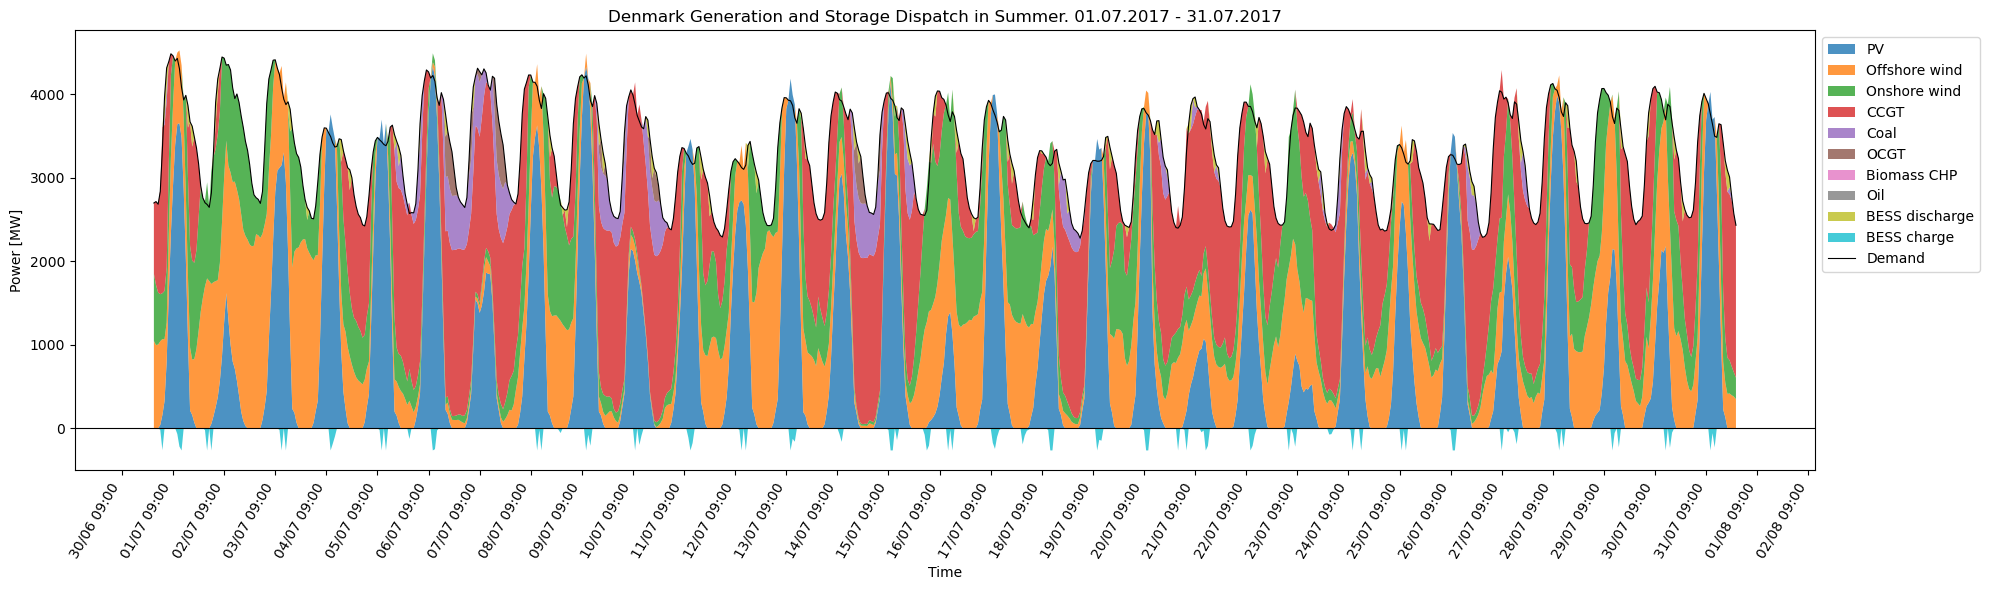

In [155]:
import numpy as np
# Date range week
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-07-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-07-31 23:00:00")
else:
    start_date = pd.Timestamp("2015-07-01 00:00:00")
    end_date   = pd.Timestamp("2015-07-31 23:00:00")

# ----------------------------
# GENERATORS
# ----------------------------
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)
dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Marginal cost ordering for generators
cost_df = n.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n.carriers.nice_name)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()
tech_order = cost_by_tech.sort_values().index.tolist()

dispatch_nice = dispatch_nice[tech_order]

# ----------------------------
# STORAGE UNITS
# ----------------------------
# Positive = discharge, negative = charge
storage_p = n.storage_units_t.p.copy()

if not storage_p.empty:
    storage_nice_map = n.storage_units.carrier.map(n.carriers.nice_name).to_dict()

    storage_nice = storage_p.rename(
        columns=lambda s: storage_nice_map.get(s, s)
    )
    storage_nice = storage_nice.T.groupby(level=0).sum().T

    storage_discharge = storage_nice.clip(lower=0)
    storage_charge = storage_nice.clip(upper=0)
else:
    storage_discharge = pd.DataFrame(index=dispatch_nice.index)
    storage_charge = pd.DataFrame(index=dispatch_nice.index)

# ----------------------------
# SLICE TIME
# ----------------------------
dispatch_plot = dispatch_nice.loc[start_date:end_date].copy()
demand_plot = work_df.loc[start_date:end_date, "demand_mw"].copy()
storage_discharge_plot = storage_discharge.loc[start_date:end_date].copy()
storage_charge_plot = storage_charge.loc[start_date:end_date].copy()

dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)
storage_discharge_plot.index = pd.to_datetime(storage_discharge_plot.index)
storage_charge_plot.index = pd.to_datetime(storage_charge_plot.index)

# ----------------------------
# PLOT
# ----------------------------
fig, ax = plt.subplots(figsize=(20, 6))
x = dispatch_plot.index

# Positive stack: generators first
pos_cum = np.zeros(len(x))
for col in dispatch_plot.columns:
    y = dispatch_plot[col].to_numpy()
    ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=col)
    pos_cum = pos_cum + y

# Positive stack: storage discharge on top
for col in storage_discharge_plot.columns:
    y = storage_discharge_plot[col].to_numpy()
    if np.any(y != 0):
        ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=f"{col} discharge")
        pos_cum = pos_cum + y

# Negative stack: storage charging below zero
neg_cum = np.zeros(len(x))
for col in storage_charge_plot.columns:
    y = storage_charge_plot[col].to_numpy()  # negative or zero
    if np.any(y != 0):
        ax.fill_between(x, neg_cum, neg_cum + y, alpha=0.8, label=f"{col} charge")
        neg_cum = neg_cum + y

# Demand line
ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    linewidth=0.8,
    color="black",
    label="Demand"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.axhline(0, color="black", linewidth=0.8)

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")

if capacity_factor_year is not None:
    ax.set_title(
        f"Denmark Generation and Storage Dispatch in Summer. "
        f"{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
    )
else:
    ax.set_title("Denmark Generation and Storage Dispatch in Summer. Capacity Factors 10 year average 2007 - 2017.")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

#### Optimal capacities

In [156]:
# Generators
gen_capacity = n.generators[["carrier", "p_nom_opt"]].copy()
gen_capacity["Technology"] = gen_capacity["carrier"].map(n.carriers.nice_name)

# Storage units
su_capacity = n.storage_units[["carrier", "p_nom_opt"]].copy()
su_capacity["Technology"] = su_capacity["carrier"].map(n.carriers.nice_name)

# Combine
capacity = pd.concat([
    gen_capacity[["Technology", "p_nom_opt"]],
    su_capacity[["Technology", "p_nom_opt"]]
], axis=0)

# Aggregate by technology
capacity_table = (
    capacity.groupby("Technology")["p_nom_opt"]
    .sum()
    .sort_values(ascending=False)
    .round(1)
)

if capacity_factor_year is not None:
    print(f"Year used for simulation: {capacity_factor_year}")
else:
    print("10 year average (2007 - 2017) was used for capacity factors")

print(capacity_table)

Year used for simulation: 2017
Technology
PV               6606.5
Onshore wind     4860.0
Offshore wind    2650.0
Biomass CHP      2000.0
CCGT             1987.9
OCGT              750.0
Coal              650.0
Oil               300.0
BESS              266.1
Name: p_nom_opt, dtype: float64


#### Dispatch curves and annual electricity generation overview

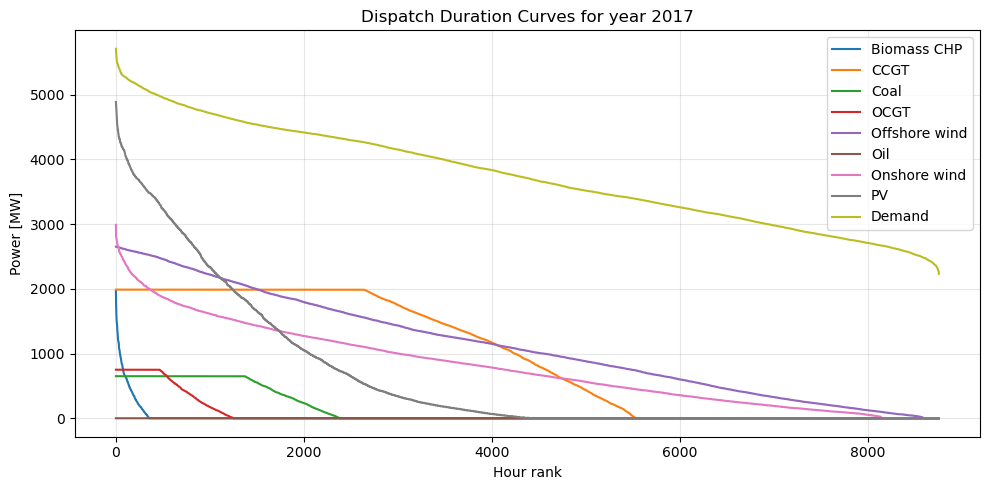

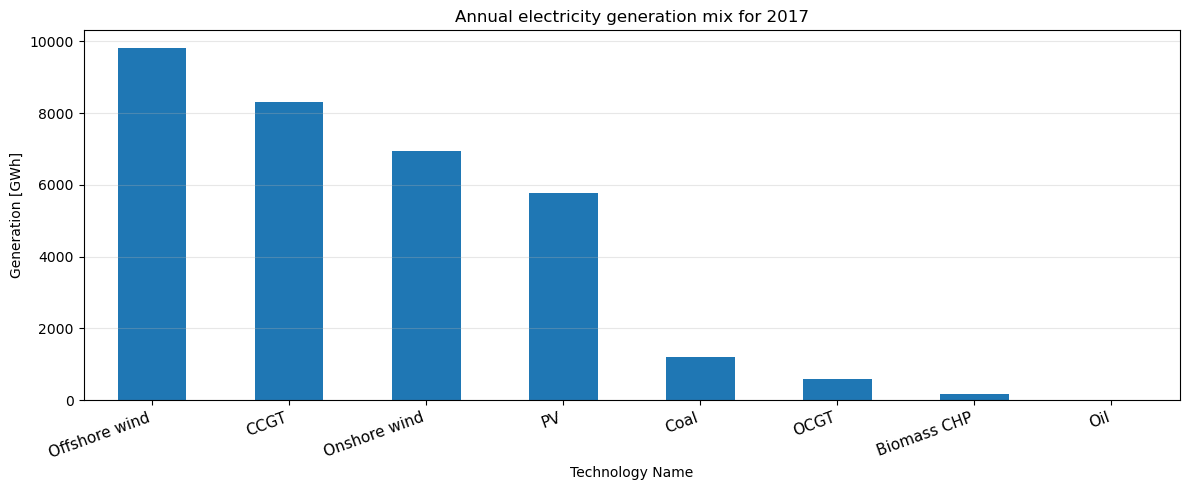


Annual storage operation:


,discharge_mwh,discharge_gwh,charge_mwh,charge_gwh
name,,,,
BESS,197719.590169,197.71959,214539.48586,214.539486


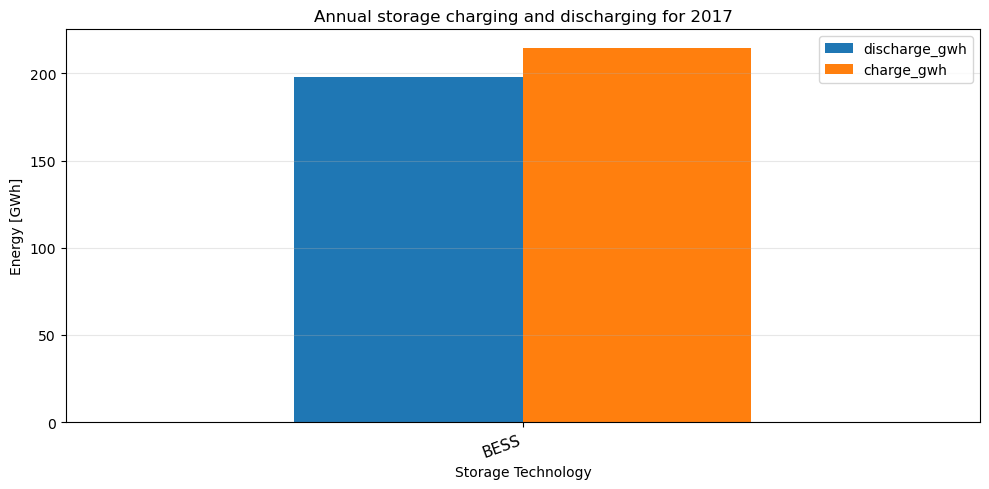

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# GENERATOR DISPATCH
# ----------------------------
gen_dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = gen_dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Add demand if you want it for duration curves
dispatch_nice["Demand"] = work_df["demand_mw"]

# ----------------------------
# DURATION CURVES
# ----------------------------
duration_df = pd.DataFrame({
    col: dispatch_nice[col].sort_values(ascending=False).values
    for col in dispatch_nice.columns
})

fig, ax = plt.subplots(figsize=(10, 5))
duration_df.plot(ax=ax)

ax.set_title(f"Dispatch Duration Curves for year {capacity_factor_year}")
ax.set_xlabel("Hour rank")
ax.set_ylabel("Power [MW]")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# ANNUAL GENERATION MIX
# Only true generators are included in the mix
# Batteries are NOT generation, so they are excluded from shares
# ----------------------------
annual_generation = dispatch_nice.drop(columns="Demand", errors="ignore").sum(axis=0)

annual_generation_df = annual_generation.to_frame(name="generation_mwh")
annual_generation_df["generation_gwh"] = annual_generation_df["generation_mwh"] / 1000

annual_generation_df["share"] = (
    annual_generation_df["generation_mwh"] /
    annual_generation_df["generation_mwh"].sum()
)
annual_generation_df["share_percent"] = 100 * annual_generation_df["share"]

annual_generation_df = annual_generation_df.sort_values("generation_mwh", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
annual_generation_df["generation_gwh"].plot.bar(ax=ax)

ax.set_ylabel("Generation [GWh]")
ax.set_xlabel("Technology Name")
ax.set_title(f"Annual electricity generation mix for {capacity_factor_year}")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# BATTERY DISCHARGE / CHARGE SUMMARY
# Shown separately because storage shifts energy, it does not generate it
# ----------------------------
storage_dispatch = n.storage_units_t.p.copy()

if not storage_dispatch.empty:
    su_carrier_series = n.storage_units.carrier

    storage_dispatch_nice = storage_dispatch.rename(
        columns=lambda s: nice_name_map.get(su_carrier_series[s], su_carrier_series[s])
    )
    storage_dispatch_nice = storage_dispatch_nice.T.groupby(level=0).sum().T

    # Positive = discharge, Negative = charge
    storage_discharge = storage_dispatch_nice.clip(lower=0)
    storage_charge = -storage_dispatch_nice.clip(upper=0)

    annual_storage_discharge = storage_discharge.sum(axis=0)
    annual_storage_charge = storage_charge.sum(axis=0)

    annual_storage_df = pd.DataFrame({
        "discharge_mwh": annual_storage_discharge,
        "discharge_gwh": annual_storage_discharge / 1000,
        "charge_mwh": annual_storage_charge,
        "charge_gwh": annual_storage_charge / 1000,
    }).sort_values("discharge_mwh", ascending=False)

    print("\nAnnual storage operation:")
    display(annual_storage_df)

    # Optional storage plot
    fig, ax = plt.subplots(figsize=(10, 5))
    annual_storage_df[["discharge_gwh", "charge_gwh"]].plot.bar(ax=ax)

    ax.set_ylabel("Energy [GWh]")
    ax.set_xlabel("Storage Technology")
    ax.set_title(f"Annual storage charging and discharging for {capacity_factor_year}")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=11)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No storage units found in the model.")

## Part D

### New countries integration

In [158]:
# Don't allow to have the 10 year average anymore as a CF setting
capacity_factor_year = 2017
if capacity_factor_year is None:
    capacity_factor_year = 2015

# Collect demand and capacity factors of new countries
offshore_wind_cf_df_raw = pd.read_csv("../data/offshore_wind_capacity_factor_raw.csv",delimiter=";")
onshore_wind_cf_df_raw = pd.read_csv("../data/onshore_wind_capacity_factor_raw.csv", delimiter=";")
pv_cf_df_raw = pd.read_csv("../data/pv_capacity_factor_raw.csv", delimiter=";")
el_demand_raw = pd.read_csv("../data/electricity_demand.csv", delimiter=";")

# Collect hydro values
hydro_hourly = pd.read_csv("../data/hydro_hourly.csv",delimiter=",")
hydro_hourly["utc_time"] = pd.to_datetime(hydro_hourly["utc_time"], utc=True, errors="raise")


# Convert ISO8601 to datetime
offshore_wind_cf_df_raw["utc_time"] = pd.to_datetime(offshore_wind_cf_df_raw["utc_time"], utc=True, errors="raise")
onshore_wind_cf_df_raw["utc_time"] = pd.to_datetime(onshore_wind_cf_df_raw["utc_time"], utc=True, errors="raise")
pv_cf_df_raw["utc_time"] = pd.to_datetime(pv_cf_df_raw["utc_time"], utc=True, errors="raise")
el_demand_raw["utc_time"] = pd.to_datetime(el_demand_raw["utc_time"], utc=True, errors="raise")

# Filter out the exact year
pv_cf_df_raw = pv_cf_df_raw[pv_cf_df_raw["utc_time"].dt.year == capacity_factor_year]
onshore_wind_cf_df_raw = onshore_wind_cf_df_raw[onshore_wind_cf_df_raw["utc_time"].dt.year == capacity_factor_year]
offshore_wind_cf_df_raw = offshore_wind_cf_df_raw[offshore_wind_cf_df_raw["utc_time"].dt.year == capacity_factor_year]
el_demand_raw["utc_time"] = el_demand_raw["utc_time"].apply(lambda t: t.replace(year=capacity_factor_year))
hydro_hourly = hydro_hourly[hydro_hourly["utc_time"].dt.year == capacity_factor_year]

# Norway
df_pv_no = pv_cf_df_raw[["utc_time", "NOR"]]
df_onshore_wind_no = onshore_wind_cf_df_raw[["utc_time", "NOR"]]
df_offshore_wind_no = offshore_wind_cf_df_raw[["utc_time", "NOR"]]
el_demand_no = el_demand_raw[["utc_time", "NOR"]]
hydro_df_no = hydro_hourly["NO"]

# Denmark
df_pv_dk = pv_cf_df_raw[["utc_time", "DNK"]]
df_onshore_wind_dk = onshore_wind_cf_df_raw[["utc_time", "DNK"]]
df_offshore_wind_dk = offshore_wind_cf_df_raw[["utc_time", "DNK"]]
el_demand_dk = el_demand_raw[["utc_time", "DNK"]]

# Sweden
df_pv_swe = pv_cf_df_raw[["utc_time", "SWE"]]
df_onshore_wind_swe = onshore_wind_cf_df_raw[["utc_time", "SWE"]]
df_offshore_wind_swe = offshore_wind_cf_df_raw[["utc_time", "SWE"]]
el_demand_swe = el_demand_raw[["utc_time", "SWE"]]
hydro_df_se = hydro_hourly["SE"]

# Great Britain
df_pv_gbr = pv_cf_df_raw[["utc_time", "GBR"]]
df_onshore_wind_gbr = onshore_wind_cf_df_raw[["utc_time", "GBR"]]
df_offshore_wind_gbr = offshore_wind_cf_df_raw[["utc_time", "GBR"]]
el_demand_gbr = el_demand_raw[["utc_time", "GBR"]]
hydro_df_gb = hydro_hourly["GB"]

# Rename columns
df_pv_dk = df_pv_dk.rename(columns={"DNK": "cf"})
df_onshore_wind_dk = df_onshore_wind_dk.rename(columns={"DNK": "cf"})
df_offshore_wind_dk = df_offshore_wind_dk.rename(columns={"DNK": "cf"})

df_pv_no = df_pv_no.rename(columns={"NOR": "cf"})
df_onshore_wind_no = df_onshore_wind_no.rename(columns={"NOR": "cf"})
df_offshore_wind_no = df_offshore_wind_no.rename(columns={"NOR": "cf"})

df_pv_swe = df_pv_swe.rename(columns={"SWE": "cf"})
df_onshore_wind_swe = df_onshore_wind_swe.rename(columns={"SWE": "cf"})
df_offshore_wind_swe = df_offshore_wind_swe.rename(columns={"SWE": "cf"})

df_pv_gbr = df_pv_gbr.rename(columns={"GBR": "cf"})
df_onshore_wind_gbr = df_onshore_wind_gbr.rename(columns={"GBR": "cf"})
df_offshore_wind_gbr = df_offshore_wind_gbr.rename(columns={"GBR": "cf"})

# Remove year from capacity factor dataframes
df_pv_dk = hourly_climatology(df_pv_dk)
df_onshore_wind_dk = hourly_climatology(df_onshore_wind_dk)
df_offshore_wind_dk = hourly_climatology(df_offshore_wind_dk)

df_pv_no = hourly_climatology(df_pv_no)
df_onshore_wind_no = hourly_climatology(df_onshore_wind_no)
df_offshore_wind_no = hourly_climatology(df_offshore_wind_no)

df_pv_swe = hourly_climatology(df_pv_swe)
df_onshore_wind_swe = hourly_climatology(df_onshore_wind_swe)
df_offshore_wind_swe = hourly_climatology(df_offshore_wind_swe)

df_pv_gbr = hourly_climatology(df_pv_gbr)
df_onshore_wind_gbr = hourly_climatology(df_onshore_wind_gbr)
df_offshore_wind_gbr = hourly_climatology(df_offshore_wind_gbr)


# Pull converted data
df_pv_dk = df_pv_dk[["datetime", "cf"]]
df_onshore_wind_dk = df_onshore_wind_dk[["datetime", "cf"]]
df_offshore_wind_dk = df_offshore_wind_dk[["datetime", "cf"]]

df_pv_no = df_pv_no[["datetime", "cf"]]
df_onshore_wind_no = df_onshore_wind_no[["datetime", "cf"]]
df_offshore_wind_no = df_offshore_wind_no[["datetime", "cf"]]

df_pv_swe = df_pv_swe[["datetime", "cf"]]
df_onshore_wind_swe = df_onshore_wind_swe[["datetime", "cf"]]
df_offshore_wind_swe = df_offshore_wind_swe[["datetime", "cf"]]

df_pv_gbr = df_pv_gbr[["datetime", "cf"]]
df_onshore_wind_gbr = df_onshore_wind_gbr[["datetime", "cf"]]
df_offshore_wind_gbr = df_offshore_wind_gbr[["datetime", "cf"]]

# Rename columns
df_pv_dk = df_pv_dk.rename(columns={"cf": "pv_cf_dk"})
df_onshore_wind_dk = df_onshore_wind_dk.rename(columns={"cf": "onshore_cf_dk"})
df_offshore_wind_dk = df_offshore_wind_dk.rename(columns={"cf": "offshore_cf_dk"})

df_pv_no = df_pv_no.rename(columns={"cf": "pv_cf_no"})
df_onshore_wind_no = df_onshore_wind_no.rename(columns={"cf": "onshore_cf_no"})
df_offshore_wind_no = df_offshore_wind_no.rename(columns={"cf": "offshore_cf_no"})

df_pv_swe = df_pv_swe.rename(columns={"cf": "pv_cf_se"})
df_onshore_wind_swe = df_onshore_wind_swe.rename(columns={"cf": "onshore_cf_se"})
df_offshore_wind_swe = df_offshore_wind_swe.rename(columns={"cf": "offshore_cf_se"})

df_pv_gbr = df_pv_gbr.rename(columns={"cf": "pv_cf_gb"})
df_onshore_wind_gbr = df_onshore_wind_gbr.rename(columns={"cf": "onshore_cf_gb"})
df_offshore_wind_gbr = df_offshore_wind_gbr.rename(columns={"cf": "offshore_cf_gb"})

el_demand_dk = el_demand_dk.rename(columns={"DNK": "el_demand_dk"})
el_demand_no = el_demand_no.rename(columns={"NOR": "el_demand_no"})
el_demand_swe = el_demand_swe.rename(columns={"SWE": "el_demand_swe"})
el_demand_gbr = el_demand_gbr.rename(columns={"GBR": "el_demand_gbr"})

# Set index
df_pv_dk = df_pv_dk.set_index("datetime")
df_onshore_wind_dk = df_onshore_wind_dk.set_index("datetime")
df_offshore_wind_dk = df_offshore_wind_dk.set_index("datetime")

df_pv_no = df_pv_no.set_index("datetime")
df_onshore_wind_no = df_onshore_wind_no.set_index("datetime")
df_offshore_wind_no = df_offshore_wind_no.set_index("datetime")

df_pv_swe = df_pv_swe.set_index("datetime")
df_onshore_wind_swe = df_onshore_wind_swe.set_index("datetime")
df_offshore_wind_swe = df_offshore_wind_swe.set_index("datetime")

df_pv_gbr = df_pv_gbr.set_index("datetime")
df_onshore_wind_gbr = df_onshore_wind_gbr.set_index("datetime")
df_offshore_wind_gbr = df_offshore_wind_gbr.set_index("datetime")

el_demand_dk = el_demand_dk.set_index("utc_time")
el_demand_no = el_demand_no.set_index("utc_time")
el_demand_swe = el_demand_swe.set_index("utc_time")
el_demand_gbr = el_demand_gbr.set_index("utc_time")

el_demand_dk.index = pd.to_datetime(el_demand_dk.index).tz_localize(None)
el_demand_no.index = pd.to_datetime(el_demand_no.index).tz_localize(None)
el_demand_swe.index = pd.to_datetime(el_demand_swe.index).tz_localize(None)
el_demand_gbr.index = pd.to_datetime(el_demand_gbr.index).tz_localize(None)

# Concat the dataframes
work_df = pd.concat([df_pv_dk, df_onshore_wind_dk, df_offshore_wind_dk, df_pv_no, df_onshore_wind_no, 
                     df_offshore_wind_no, df_pv_swe, df_onshore_wind_swe, df_offshore_wind_swe, df_pv_gbr, df_onshore_wind_gbr,
                       df_offshore_wind_gbr], axis=1)
work_df.index = pd.to_datetime(
    str(capacity_factor_year) + "/" + work_df.index.astype(str),
    format="%Y/%d/%m %H:%M"
)

work_df = work_df.join(
    [el_demand_no, el_demand_dk, el_demand_swe, el_demand_gbr],
    how="left"
)


### New technologies integration

In [159]:
# New technologies: hydro, nuclear

# Technology lifetimes
hydro_lifetime = 60 # years
nuclear_lifetime = 60 # years

# CAPEX
hydro_capex = 1720000 # EUR/MW
nuclear_capex = 5500000 # EUR/MW

# Annualised capital costs
annualised_hydro_capex = hydro_capex / hydro_lifetime # EUR/MW/year
annualsied_nuclear_capex = nuclear_capex / nuclear_lifetime # EUR/MW/year

# Annual OPEX costs
hydro_opex = 20*1000 # EUR/MW/year
nuclear_opex = 150 * 1000 # EUR/MW/year

# Setting up marginal generation costs
nuclear_marginal_cost = 14 # EUR/MWh
hydro_marginal_cost = 2 # EUR/MWh


### PyPsa model setup

In [160]:
n = pypsa.Network()

# Set time snapshots
n.set_snapshots(work_df.index)

# Fix hydro index
hydro_df_gb.index = n.snapshots
hydro_df_se.index = n.snapshots
hydro_df_no.index = n.snapshots

# Carriers
n.add("Carrier","OnshoreWind",co2_emissions=0,nice_name="Onshore wind")
n.add("Carrier","OffshoreWind",co2_emissions=0,nice_name="Offshore wind")
n.add("Carrier","PV",co2_emissions=0,nice_name="PV")
n.add("Carrier","AC",co2_emissions=0)
n.add("Carrier","BiomassCHP",co2_emissions=0,nice_name="Biomass CHP")
n.add("Carrier","CCGT",co2_emissions=0,nice_name="CCGT")
n.add("Carrier","OCGT",co2_emissions=0,nice_name="OCGT")
n.add("Carrier","Hydro",co2_emissions=0,nice_name="Hydro")
n.add("Carrier","Nuclear",co2_emissions=0,nice_name="Nuclear")
n.add("Carrier","Coal",co2_emissions=0,nice_name="Coal")
n.add("Carrier","Oil",co2_emissions=0,nice_name="Oil")
n.add("Carrier","BESS",co2_emissions=0,nice_name="BESS")

# Buses
n.add("Bus","DK",carrier="AC",v_nom=400)
n.add("Bus","SWE",carrier="AC",v_nom=400)
n.add("Bus","NO",carrier="AC",v_nom=400)
n.add("Bus","GB",carrier="AC",v_nom=400)

# Load
n.add("Load","DKLoad",bus="DK",p_set=work_df["el_demand_dk"].to_numpy())
n.add("Load","SWELoad",bus="SWE",p_set=work_df["el_demand_swe"].to_numpy())
n.add("Load","NOLoad",bus="NO",p_set=work_df["el_demand_no"].to_numpy())
n.add("Load","GBRLoad",bus="GB",p_set=work_df["el_demand_gbr"].to_numpy())

# DK Generators
n.add("Generator","DKOffshoreWind",bus="DK",carrier="OffshoreWind",p_nom_extendable=True,p_nom_min=2650,p_nom = 2650,p_max_pu = work_df["offshore_cf_dk"].to_numpy(),marginal_cost=float(offshore_wind_marginal_cost),capital_cost=float(annualised_offshore_wind_capex + offshore_wind_opex))
n.add("Generator","DKOnshoreWind",bus="DK",carrier="OnshoreWind",p_nom_extendable=True,p_nom_min=4860,p_nom= 4860,p_max_pu = work_df["onshore_cf_dk"].to_numpy(),marginal_cost=float(onshore_wind_marginal_cost),capital_cost=float(annualised_onshore_wind_capex + onshore_wind_opex))
n.add("Generator","DKPV",bus="DK",carrier="PV",p_nom_extendable=True,p_nom_min=4800,p_nom=4800,p_max_pu = work_df["pv_cf_dk"].to_numpy(),marginal_cost=float(pv_marginal_cost),capital_cost=float(annualised_pv_capex + pv_opex))
n.add("Generator","DKBiomassCHP",bus="DK",carrier="BiomassCHP",p_nom_extendable=True,p_nom_min=2000,p_nom=2000,marginal_cost=float(chp_marginal_cost),capital_cost=float(annualised_chp_capex + chp_opex))
n.add("Generator","DKCCGT",bus="DK",carrier="CCGT",p_nom_extendable=True,p_nom_min=1750,p_nom=1750,marginal_cost=float(ccgt_marginal_cost),capital_cost=float(annualised_ccgt_capex + ccgt_opex))
n.add("Generator","DKOCGT",bus="DK",carrier="OCGT",p_nom_extendable=True,p_nom_min=750,p_nom=750,marginal_cost=float(ocgt_marginal_cost),capital_cost=float(annualised_ocgt_capex + ocgt_opex))
n.add("Generator","DKCoal",bus="DK",carrier="Coal",p_nom_extendable=True,p_nom_min=650,p_nom=650,marginal_cost=coal_marginal_cost,capital_cost=annualised_coal_capex + coal_opex)
n.add("Generator","DKOil",bus="DK",carrier="Oil",p_nom_extendable=True,p_nom_min=300,p_nom=300,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

# UK generators
n.add("StorageUnit","GBHydro",bus="GB",carrier="Hydro",p_nom=2000,p_nom_min=2000,max_hours=450, p_nom_extendable=False,efficiency_dispatch=0.9,standing_loss=0.0,cyclic_state_of_charge=False,state_of_charge_initial=0.5 * 2000 * 450,marginal_cost=hydro_marginal_cost,capital_cost=annualised_hydro_capex + hydro_opex)
n.storage_units_t.inflow["GBHydro"] = hydro_df_gb
n.add("Generator","GBWind",bus="GB",carrier="OnshoreWind",p_nom_min=32000,p_nom=32000,p_max_pu = work_df["onshore_cf_gb"].to_numpy(),p_nom_extendable=True,marginal_cost=float(onshore_wind_marginal_cost),capital_cost= annualised_onshore_wind_capex + onshore_wind_opex)
n.add("Generator","GBPV",bus="GB",carrier="PV",p_nom_min=15000,p_nom=15000,p_max_pu = work_df["pv_cf_gb"].to_numpy(),p_nom_extendable=True,marginal_cost=float(pv_marginal_cost),capital_cost = annualised_pv_capex + pv_opex)
n.add("Generator","GBNuclear",bus="GB",carrier="Nuclear",p_nom_min=7000,p_nom=7000,p_nom_extendable=True,marginal_cost=nuclear_marginal_cost,capital_cost = annualsied_nuclear_capex + nuclear_opex)
n.add("Generator","GBCCGT",bus="GB",carrier="CCGT",p_nom_min=33000,p_nom=33000,p_nom_extendable=True,marginal_cost=float(ccgt_marginal_cost),capital_cost=annualised_ccgt_capex + ccgt_opex)
n.add("Generator","GBBiomassCHP",bus="GB",carrier="BiomassCHP",p_nom_min=7000,p_nom=7000,p_nom_extendable=True,marginal_cost=chp_marginal_cost,capital_cost=annualised_chp_capex + chp_opex)
n.add("Generator","GBOil",bus="GB",carrier="Oil",p_nom_extendable=True,p_nom_min=2000,p_nom=2000,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

# Sweden generators
n.add("StorageUnit","SEHydro",bus="SWE",carrier="Hydro",p_nom=16000,p_nom_min=16000,max_hours=2125,p_nom_extendable=False,efficiency_dispatch=0.9,standing_loss=0.0,cyclic_state_of_charge=False,state_of_charge_initial=0.5 * 16000 * 2125,marginal_cost=hydro_marginal_cost,capital_cost=annualised_hydro_capex + hydro_opex)
n.storage_units_t.inflow["SEHydro"] = hydro_df_se
n.add("Generator","SEWind",bus="SWE",carrier="OnshoreWind",p_nom=16000,p_nom_min=16000,p_max_pu = work_df["onshore_cf_se"].to_numpy(),p_nom_extendable=True,marginal_cost=float(onshore_wind_marginal_cost),capital_cost=annualised_onshore_wind_capex + onshore_wind_opex)
n.add("Generator","SEPV",bus="SWE",carrier="PV",p_nom=3000,p_nom_min=3000,p_max_pu = work_df["pv_cf_se"].to_numpy(),p_nom_extendable=True,marginal_cost=float(pv_marginal_cost),capital_cost=annualised_pv_capex + pv_opex)
n.add("Generator","SENuclear",bus="SWE",carrier="Nuclear",p_nom=7500,p_nom_min=7500,p_nom_extendable=True,marginal_cost=nuclear_marginal_cost,capital_cost=annualsied_nuclear_capex + nuclear_opex)
n.add("Generator","SECCGT",bus="SWE",carrier="CCGT",p_nom=2000,p_nom_min=2000,p_nom_extendable=True,marginal_cost=float(ccgt_marginal_cost),capital_cost=annualised_ccgt_capex + ccgt_opex)
n.add("Generator","SEBiomassCHP",bus="SWE",carrier="BiomassCHP",p_nom=5000,p_nom_min=5000,p_nom_extendable=True,marginal_cost=chp_marginal_cost,capital_cost=annualised_chp_capex + chp_opex)
n.add("Generator","SEOil",bus="SWE",carrier="Oil",p_nom_extendable=True,p_nom=750,p_nom_min=750,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

# Norway generators
n.add("StorageUnit","NOHydro",bus="NO",carrier="Hydro",p_nom=34000,p_nom_min=34000,max_hours=2500,p_nom_extendable=False,efficiency_dispatch=0.9,standing_loss=0.0,cyclic_state_of_charge=False,state_of_charge_initial=0.5 * 34000 * 2500,marginal_cost=hydro_marginal_cost,capital_cost=annualised_hydro_capex + hydro_opex,)
n.storage_units_t.inflow["NOHydro"] = hydro_df_no
n.add("Generator","NOWind",bus="NO",carrier="OnshoreWind",p_nom=5000,p_nom_min=5000,p_max_pu = work_df["onshore_cf_no"].to_numpy(),p_nom_extendable=True,marginal_cost=float(onshore_wind_marginal_cost),capital_cost=annualised_onshore_wind_capex + onshore_wind_opex)
n.add("Generator","NOCCGT",bus="NO",carrier="CCGT",p_nom=1500,p_nom_min=1500,p_nom_extendable=True,marginal_cost=float(ccgt_marginal_cost),capital_cost=annualised_ccgt_capex + ccgt_opex)
n.add("Generator","NOOil",bus="NO",carrier="Oil",p_nom_extendable=True,p_nom=100,p_nom_min=100,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

# Lines
n.add("Line","DK-SWE",bus0="DK",bus1="SWE",s_nom=2415,x = 0.1,r = 0)
n.add("Line","SWE-NO",bus0="SWE",bus1="NO",s_nom=4000,x = 0.1,r = 0)
n.add("Line","NO-DK",bus0="NO",bus1="DK",s_nom=1700,x = 0.1,r = 0)
n.add("Line","DK-GB",bus0="DK",bus1="GB",s_nom=1400,x = 0.1,r = 0)

# Storage Units
battery_total_annualised_capex = annualised_battery_inverter_capex + battery_opex
n.add("StorageUnit","DKBESS",bus="DK",carrier="BESS",p_nom_extendable=True,p_nom=100,p_nom_min=100,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)
n.add("StorageUnit","NOBESS",bus="NO",carrier="BESS",p_nom_extendable=True,p_nom=125,p_nom_min=125,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)
n.add("StorageUnit","SEBESS",bus="SWE",carrier="BESS",p_nom_extendable=True,p_nom=450,p_nom_min=450,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)
n.add("StorageUnit","GBBESS",bus="GB",carrier="BESS",p_nom_extendable=True,p_nom=6900,p_nom_min=6900,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)


### Gurobi

In [161]:
n.optimize(
    solver_name="gurobi",
    solver_options = {
    "OutputFlag": 0
    }
)

Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 116.61it/s]

Set parameter Username



INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2815072


INFO:gurobipy:Set parameter LicenseID to value 2815072


...

Reading time = 1.31 seconds


INFO:gurobipy:Reading time = 1.31 seconds


obj: 946107 rows, 446788 columns, 1827015 nonzeros


INFO:gurobipy:obj: 946107 rows, 446788 columns, 1827015 nonzeros


('ok', 'optimal')

### Results

#### Summer week results

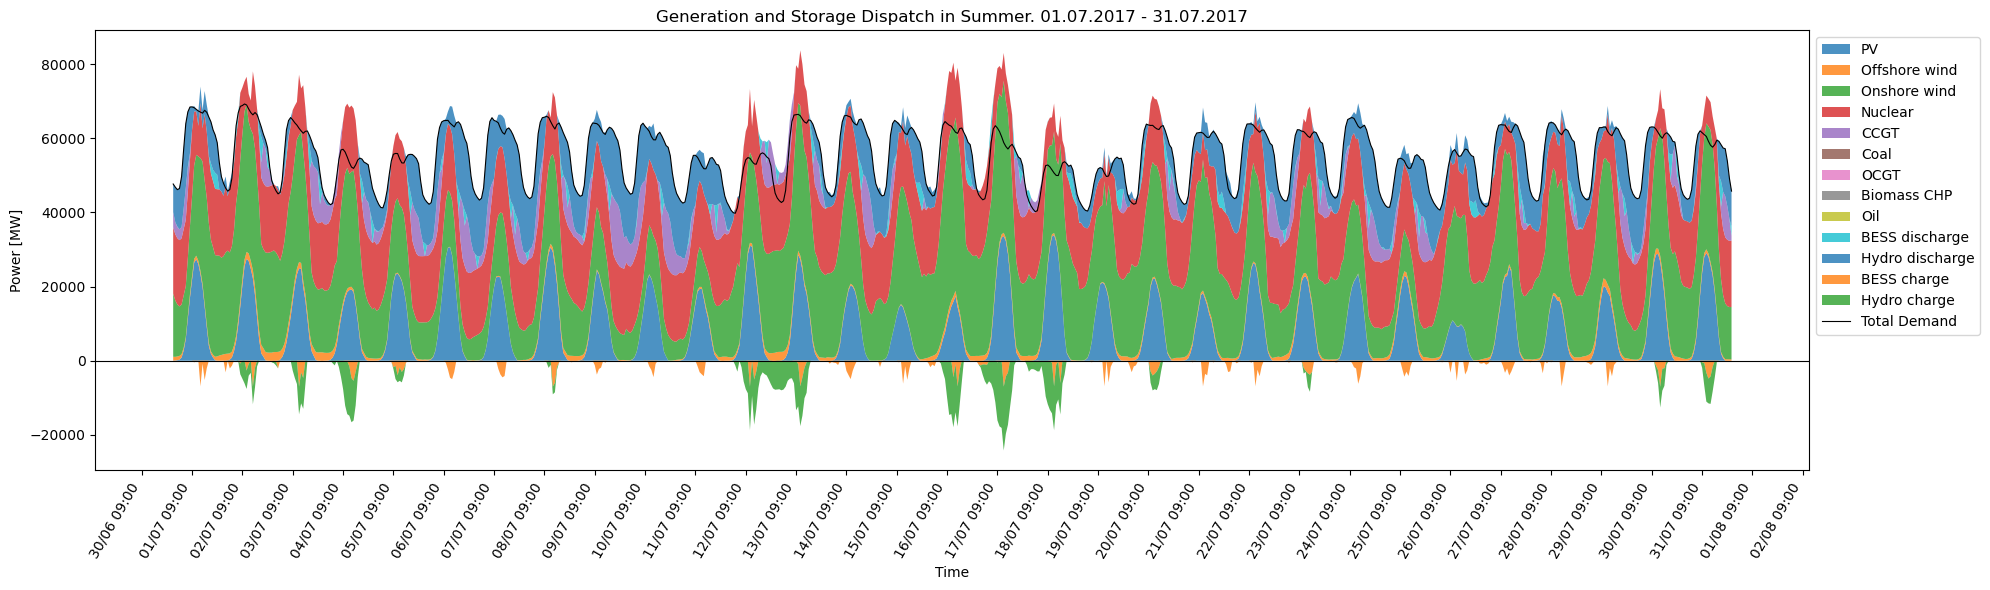

In [162]:
import numpy as np
# Date range winter week

start_date = pd.Timestamp(f"{capacity_factor_year}-07-01 00:00:00")
end_date   = pd.Timestamp(f"{capacity_factor_year}-07-31 23:00:00")

# ----------------------------
# GENERATORS
# ----------------------------
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)
dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Marginal cost ordering for generators
cost_df = n.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n.carriers.nice_name)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()
tech_order = cost_by_tech.sort_values().index.tolist()

dispatch_nice = dispatch_nice[tech_order]

# ----------------------------
# STORAGE UNITS
# ----------------------------
# Positive = discharge, negative = charge
storage_p = n.storage_units_t.p.copy()

if not storage_p.empty:
    storage_nice_map = n.storage_units.carrier.map(n.carriers.nice_name).to_dict()

    storage_nice = storage_p.rename(
        columns=lambda s: storage_nice_map.get(s, s)
    )
    storage_nice = storage_nice.T.groupby(level=0).sum().T

    storage_discharge = storage_nice.clip(lower=0)
    storage_charge = storage_nice.clip(upper=0)
else:
    storage_discharge = pd.DataFrame(index=dispatch_nice.index)
    storage_charge = pd.DataFrame(index=dispatch_nice.index)

# ----------------------------
# SLICE TIME
# ----------------------------
dispatch_plot = dispatch_nice.loc[start_date:end_date].copy()
demand_cols = ["el_demand_dk", "el_demand_no", "el_demand_swe", "el_demand_gbr"]
demand_plot = work_df.loc[start_date:end_date, demand_cols].sum(axis=1).copy()
storage_discharge_plot = storage_discharge.loc[start_date:end_date].copy()
storage_charge_plot = storage_charge.loc[start_date:end_date].copy()

dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)
storage_discharge_plot.index = pd.to_datetime(storage_discharge_plot.index)
storage_charge_plot.index = pd.to_datetime(storage_charge_plot.index)

# ----------------------------
# PLOT
# ----------------------------
fig, ax = plt.subplots(figsize=(20, 6))
x = dispatch_plot.index

# Positive stack: generators first
pos_cum = np.zeros(len(x))
for col in dispatch_plot.columns:
    y = dispatch_plot[col].to_numpy()
    ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=col)
    pos_cum = pos_cum + y

# Positive stack: storage discharge on top
for col in storage_discharge_plot.columns:
    y = storage_discharge_plot[col].to_numpy()
    if np.any(y != 0):
        ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=f"{col} discharge")
        pos_cum = pos_cum + y

# Negative stack: storage charging below zero
neg_cum = np.zeros(len(x))
for col in storage_charge_plot.columns:
    y = storage_charge_plot[col].to_numpy()  # negative or zero
    if np.any(y != 0):
        ax.fill_between(x, neg_cum, neg_cum + y, alpha=0.8, label=f"{col} charge")
        neg_cum = neg_cum + y

# Demand line
ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    linewidth=0.8,
    color="black",
    label="Total Demand"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.axhline(0, color="black", linewidth=0.8)

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")

if capacity_factor_year is not None:
    ax.set_title(
        f"Generation and Storage Dispatch in Summer. "
        f"{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
    )
else:
    ax.set_title("Generation and Storage Dispatch in Summer. Capacity Factors 10 year average 2007 - 2017.")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

#### Countries electricity profile oveview

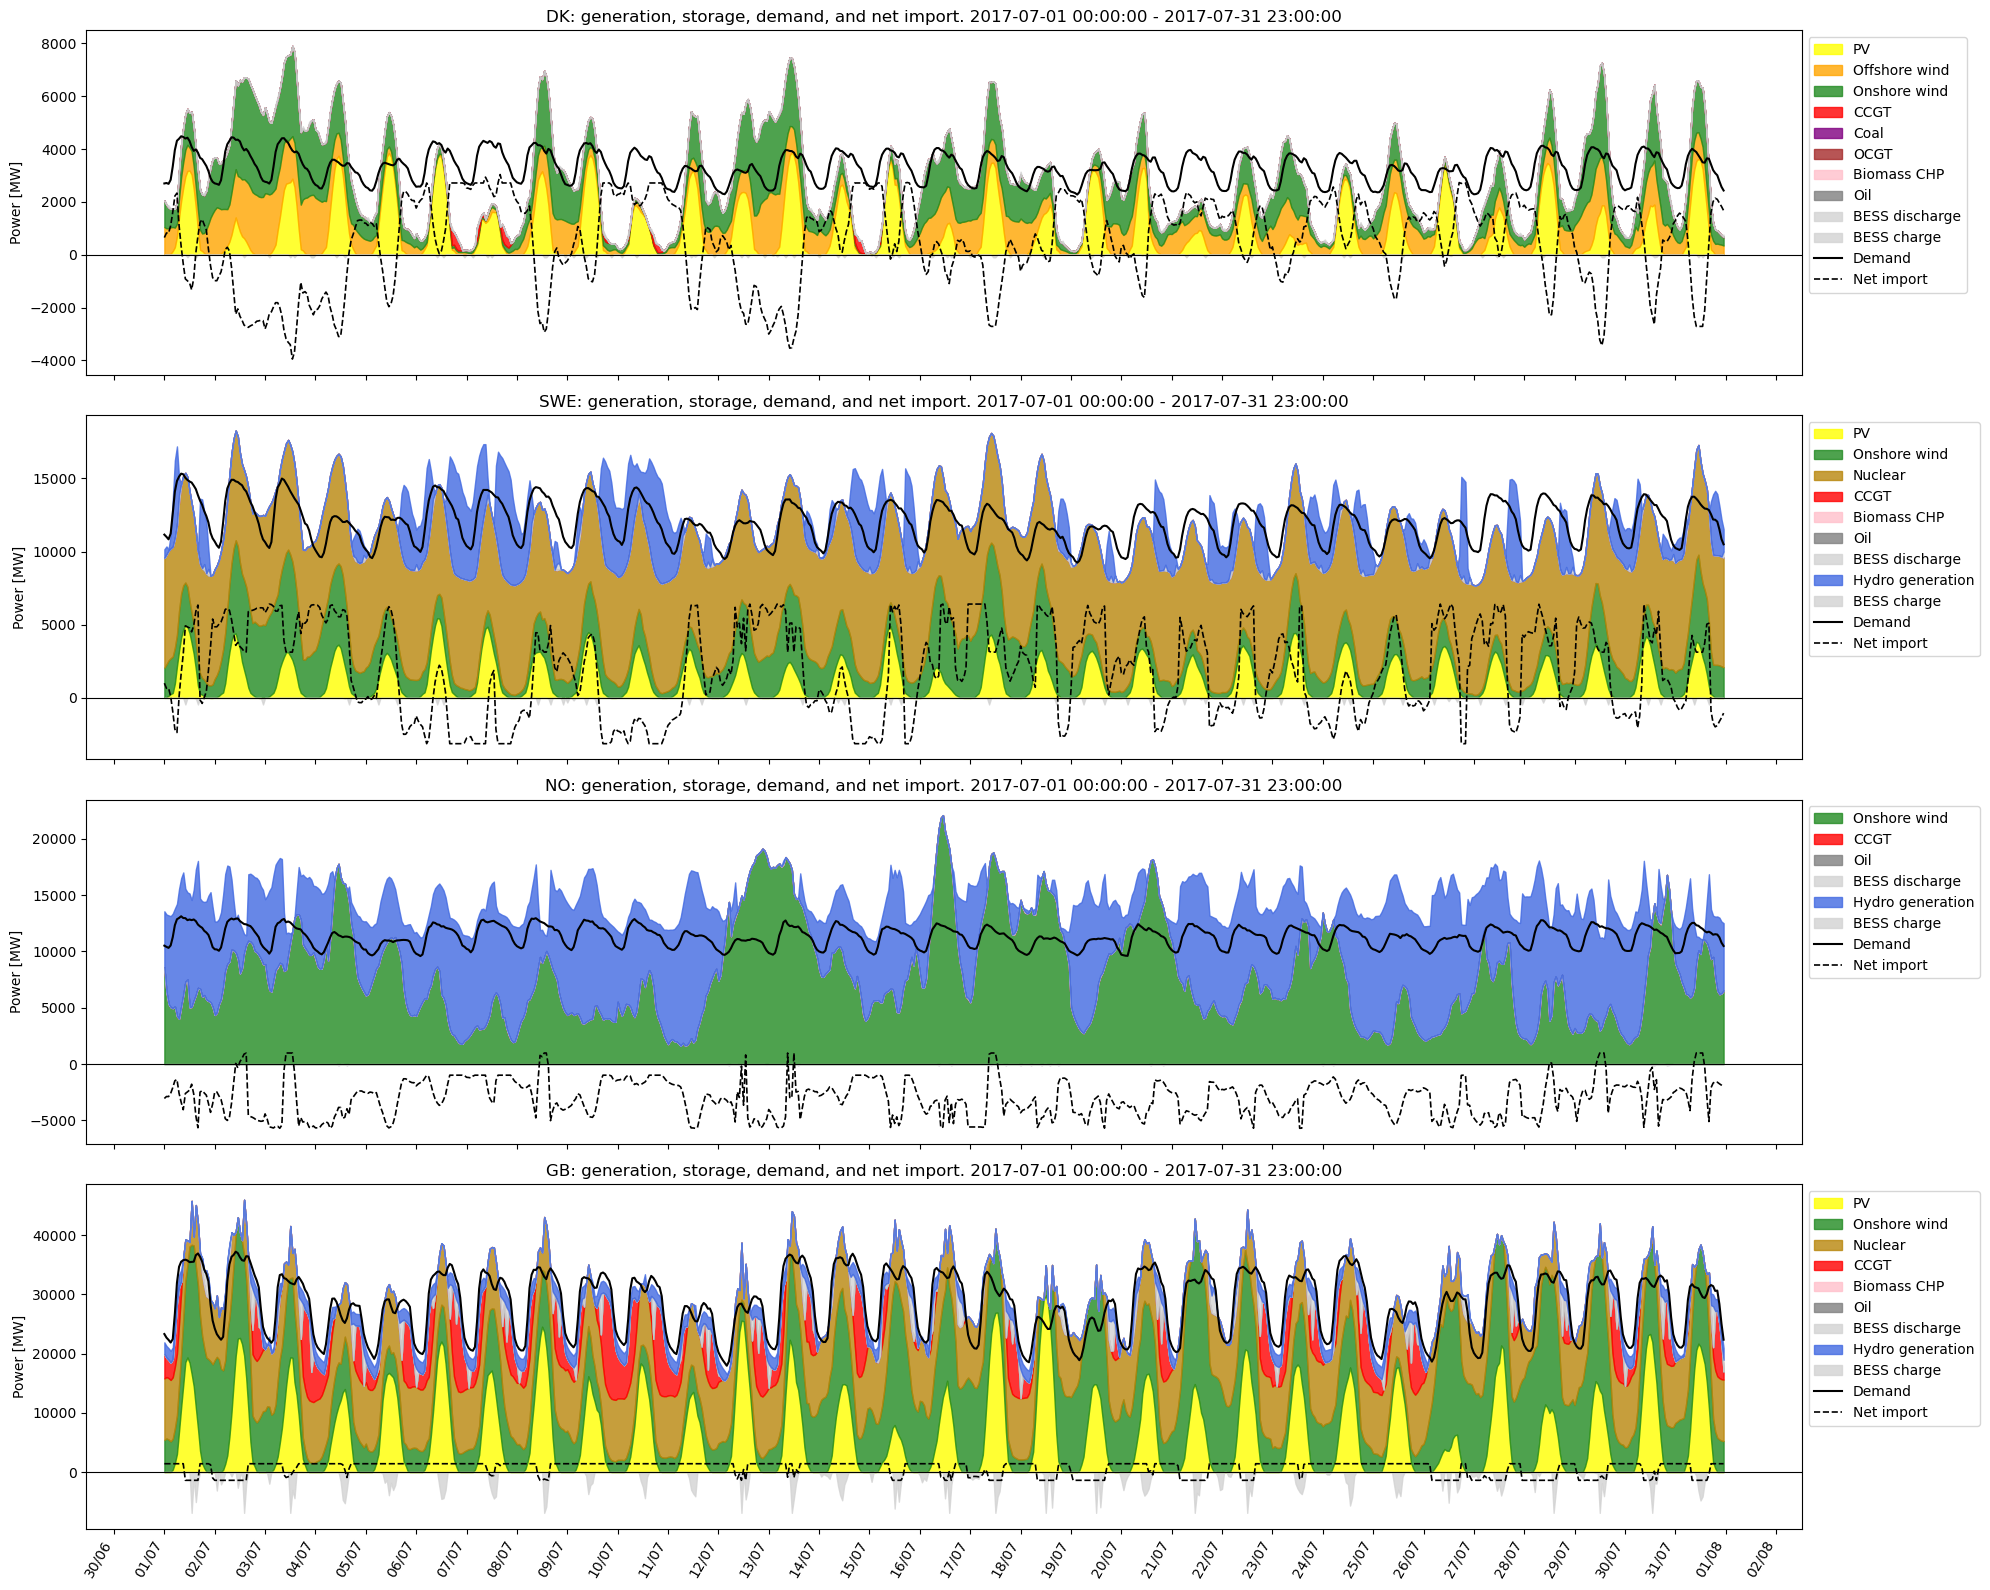

In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ----------------------------
# CONSISTENT COLORS
# ----------------------------
tech_colors = {
    "Demand": "black",
    "PV": "yellow",
    "Onshore wind": "forestgreen",
    "Offshore wind": "orange",
    "CCGT": "red",
    "OCGT": "brown",
    "Coal": "purple",
    "Biomass CHP": "pink",
    "Oil": "gray",
    "Hydro": "royalblue",
    "Battery": "olive", 
    "Nuclear": "darkgoldenrod",
    "Battery discharge": "#1b5e20",
    "Battery charge": "#1b5e20"
}

# ----------------------------
# TIME WINDOW
# ----------------------------
start_date = pd.Timestamp(f"{capacity_factor_year}-07-01 00:00:00")
end_date   = pd.Timestamp(f"{capacity_factor_year}-07-31 23:00:00")

countries = ["DK", "SWE", "NO", "GB"]

# ----------------------------
# GENERATOR DISPATCH BY COUNTRY AND TECH
# ----------------------------
gen_dispatch = n.generators_t.p.loc[start_date:end_date].copy()

gen_meta = n.generators[["bus", "carrier", "marginal_cost"]].copy()
gen_meta["nice_name"] = gen_meta["carrier"].map(n.carriers.nice_name).fillna(gen_meta["carrier"])

# technology order from average marginal cost
tech_order = (
    gen_meta.groupby("nice_name")["marginal_cost"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

# ----------------------------
# STORAGE BY COUNTRY AND TECH
# ----------------------------
storage_dispatch = n.storage_units_t.p.loc[start_date:end_date].copy()

if not storage_dispatch.empty:
    su_meta = n.storage_units[["bus", "carrier"]].copy()
    su_meta["nice_name"] = su_meta["carrier"].map(n.carriers.nice_name).fillna(su_meta["carrier"])
else:
    su_meta = pd.DataFrame(columns=["bus", "carrier", "nice_name"])

# ----------------------------
# LOAD BY COUNTRY
# ----------------------------
load_dispatch = n.loads_t.p_set.loc[start_date:end_date].copy()
load_meta = n.loads[["bus"]].copy()

# ----------------------------
# LINE FLOWS
# ----------------------------
line_p0 = n.lines_t.p0.loc[start_date:end_date].copy()
line_meta = n.lines[["bus0", "bus1"]].copy()

# ----------------------------
# HELPER FUNCTIONS
# ----------------------------
def get_country_generation(country):
    gens = gen_meta.index[gen_meta["bus"] == country]
    if len(gens) == 0:
        return pd.DataFrame(index=gen_dispatch.index)

    df = gen_dispatch[gens].copy()
    rename_map = gen_meta.loc[gens, "nice_name"].to_dict()
    df = df.rename(columns=rename_map)
    df = df.T.groupby(level=0).sum().T

    ordered_cols = [c for c in tech_order if c in df.columns]
    return df[ordered_cols]

def get_country_storage(country):
    sus = su_meta.index[su_meta["bus"] == country]
    if len(sus) == 0:
        empty = pd.DataFrame(index=gen_dispatch.index)
        return empty, empty

    df = storage_dispatch[sus].copy()
    rename_map = su_meta.loc[sus, "nice_name"].to_dict()
    df = df.rename(columns=rename_map)
    df = df.T.groupby(level=0).sum().T

    discharge = df.clip(lower=0)
    charge = df.clip(upper=0)
    return discharge, charge

def get_country_demand(country):
    loads = load_meta.index[load_meta["bus"] == country]
    if len(loads) == 0:
        return pd.Series(0.0, index=gen_dispatch.index, name=f"{country}_demand")

    return load_dispatch[loads].sum(axis=1)

def get_country_net_import(country):
    """
    Positive value = net import into country
    Negative value = net export from country
    """
    net_import = pd.Series(0.0, index=line_p0.index)

    for line in line_meta.index:
        bus0 = line_meta.loc[line, "bus0"]
        bus1 = line_meta.loc[line, "bus1"]
        p0 = line_p0[line]

        # p0 > 0 means flow bus0 -> bus1
        # import into bus0 = -p0
        # import into bus1 = +p0
        if country == bus0:
            net_import = net_import - p0
        elif country == bus1:
            net_import = net_import + p0

    return net_import

# ----------------------------
# PLOT COUNTRY-BY-COUNTRY
# ----------------------------
fig, axes = plt.subplots(len(countries), 1, figsize=(20, 4 * len(countries)), sharex=True)

if len(countries) == 1:
    axes = [axes]

for ax, country in zip(axes, countries):
    gen_df = get_country_generation(country)
    storage_discharge_df, storage_charge_df = get_country_storage(country)
    demand = get_country_demand(country)
    net_import = get_country_net_import(country)

    x = gen_df.index if not gen_df.empty else demand.index

    # positive stack: generation
    pos_cum = np.zeros(len(x))
    for col in gen_df.columns:
        y = gen_df[col].to_numpy()
        color = tech_colors.get(col, "lightgray")
        ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=col, color=color)
        pos_cum = pos_cum + y

    # positive stack: storage discharge
    for col in storage_discharge_df.columns:
        y = storage_discharge_df[col].to_numpy()
        if np.any(y != 0):
            label = "Hydro generation" if col == "Hydro" else f"{col} discharge"
            color = tech_colors.get(col, "lightgray")
            ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=label, color=color)
            pos_cum = pos_cum + y

    # negative stack: storage charge
    neg_cum = np.zeros(len(x))
    for col in storage_charge_df.columns:
        if "Hydro" in col:
            continue
        y = storage_charge_df[col].to_numpy()   # negative or zero
        if np.any(y != 0):
            color = tech_colors.get(col, "lightgray")
            ax.fill_between(x, neg_cum, neg_cum + y, alpha=0.8, label=f"{col} charge", color=color)
            neg_cum = neg_cum + y

    # demand line
    ax.plot(x, demand.to_numpy(), color=tech_colors["Demand"], linewidth=1.5, label="Demand")

    # net import line
    ax.plot(x, net_import.to_numpy(), linestyle="--", linewidth=1.2, color="black", label="Net import")

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Power [MW]")
    ax.set_title(f"{country}: generation, storage, demand, and net import. {start_date} - {end_date}")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))

axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
plt.setp(axes[-1].get_xticklabels(), rotation=60, ha="right")

plt.tight_layout()
plt.show()

#### Bar chart of countries generation by technology

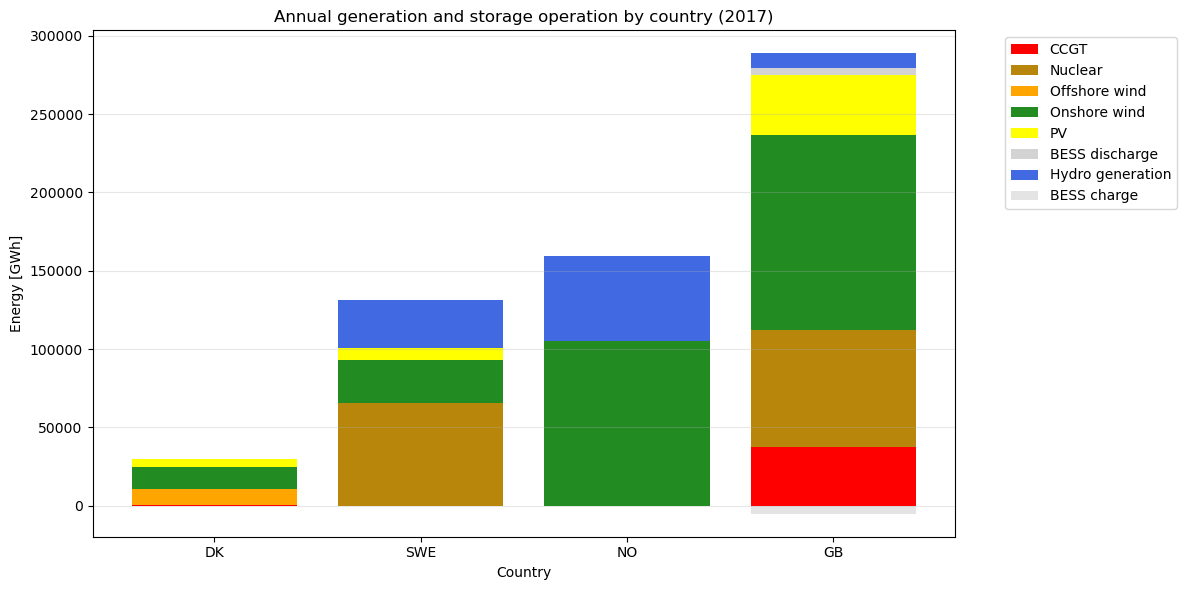

In [164]:
# ----------------------------
# PREPARE GENERATION
# ----------------------------
gen_dispatch_raw = n.generators_t.p.copy()

gen_meta = n.generators[["bus", "carrier"]].copy()
nice_name_map = n.carriers.nice_name.to_dict()

# ----------------------------
# PREPARE STORAGE
# ----------------------------
storage_dispatch_raw = n.storage_units_t.p.copy()

if not storage_dispatch_raw.empty:
    su_meta = n.storage_units[["bus", "carrier"]].copy()

    # Split charge / discharge from RAW data
    storage_discharge_raw = storage_dispatch_raw.clip(lower=0)
    storage_charge_raw = -storage_dispatch_raw.clip(upper=0)

else:
    su_meta = pd.DataFrame(columns=["bus", "carrier"])
    storage_discharge_raw = pd.DataFrame(index=gen_dispatch_raw.index)
    storage_charge_raw = pd.DataFrame(index=gen_dispatch_raw.index)

# ----------------------------
# BUILD COUNTRY-TECH MATRICES
# ----------------------------
countries = n.buses.index.tolist()

gen_techs = sorted(
    set(nice_name_map.get(c, c) for c in n.generators["carrier"].unique())
)
storage_techs = sorted(
    set(nice_name_map.get(c, c) for c in n.storage_units["carrier"].unique())
) if not n.storage_units.empty else []

all_techs = sorted(set(gen_techs) | set(storage_techs))

country_gen = pd.DataFrame(0.0, index=countries, columns=all_techs)
country_storage_dis = pd.DataFrame(0.0, index=countries, columns=all_techs)
country_storage_ch = pd.DataFrame(0.0, index=countries, columns=all_techs)

# --- Generators
for gen in n.generators.index:
    country = n.generators.loc[gen, "bus"]
    tech = nice_name_map.get(n.generators.loc[gen, "carrier"], n.generators.loc[gen, "carrier"])
    country_gen.loc[country, tech] += gen_dispatch_raw[gen].sum()

# --- Storage discharge
for su in n.storage_units.index:
    country = n.storage_units.loc[su, "bus"]
    tech = nice_name_map.get(n.storage_units.loc[su, "carrier"], n.storage_units.loc[su, "carrier"])
    country_storage_dis.loc[country, tech] += storage_discharge_raw[su].sum()

# --- Storage charge
for su in n.storage_units.index:
    country = n.storage_units.loc[su, "bus"]
    tech = nice_name_map.get(n.storage_units.loc[su, "carrier"], n.storage_units.loc[su, "carrier"])

    # Skip hydro charging completely
    if tech == "Hydro":
        continue

    country_storage_ch.loc[country, tech] += storage_charge_raw[su].sum()

# Convert to GWh
country_gen /= 1000
country_storage_dis /= 1000
country_storage_ch /= 1000

# Remove technologies that are zero everywhere
country_gen = country_gen.loc[:, (country_gen != 0).any(axis=0)]
country_storage_dis = country_storage_dis.loc[:, (country_storage_dis != 0).any(axis=0)]
country_storage_ch = country_storage_ch.loc[:, (country_storage_ch != 0).any(axis=0)]

# ----------------------------
# PLOT
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

countries_plot = country_gen.index
bottom = np.zeros(len(countries_plot))

# generation
for tech in country_gen.columns:
    values = country_gen[tech].values
    if np.any(values > 0):
        ax.bar(
            countries_plot,
            values,
            bottom=bottom,
            label=tech,
            color=tech_colors.get(tech, "lightgray")
        )
        bottom += values

# storage discharge
for tech in country_storage_dis.columns:
    values = country_storage_dis[tech].values
    if np.any(values > 0):
        label = "Hydro generation" if tech == "Hydro" else f"{tech} discharge"
        ax.bar(
            countries_plot,
            values,
            bottom=bottom,
            label=label,
            color=tech_colors.get(tech, "lightgray")
        )
        bottom += values

# storage charge (negative) -- no hydro charge
bottom_neg = np.zeros(len(countries_plot))
for tech in country_storage_ch.columns:
    values = -country_storage_ch[tech].values
    if np.any(values < 0):
        ax.bar(
            countries_plot,
            values,
            bottom=bottom_neg,
            label=f"{tech} charge",
            color=tech_colors.get(tech, "lightgray"),
            alpha=0.6
        )
        bottom_neg += values

ax.set_ylabel("Energy [GWh]")
ax.set_xlabel("Country")
ax.set_title(f"Annual generation and storage operation by country ({capacity_factor_year})")
ax.grid(axis="y", alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### Technologies production by country

In [165]:
# ----------------------------
# NUMERIC TABLES PER COUNTRY AND TECHNOLOGY
# Uses:
# - country_gen
# - country_storage_dis
# - country_storage_ch
# from the previous block
# ----------------------------

# Rename for clearer presentation
country_gen_num = country_gen.copy()
country_storage_dis_num = country_storage_dis.copy()
country_storage_ch_num = country_storage_ch.copy()

# Rename storage discharge columns
country_storage_dis_num = country_storage_dis_num.rename(
    columns=lambda c: "Hydro generation" if c == "Hydro" else f"{c} discharge"
)

# Rename storage charge columns
country_storage_ch_num = country_storage_ch_num.rename(
    columns=lambda c: f"{c} charge"
)

# Combine into one table
country_energy_table = pd.concat(
    [country_gen_num, country_storage_dis_num, -country_storage_ch_num],
    axis=1
)

# Group in case names overlap
country_energy_table = country_energy_table.T.groupby(level=0).sum().T

# Round nicely
country_energy_table_rounded = country_energy_table.round(2)

print("Annual generation and storage operation by country [GWh]:")
display(country_energy_table_rounded)

Annual generation and storage operation by country [GWh]:


,BESS charge,BESS discharge,CCGT,Hydro generation,Nuclear,Offshore wind,Onshore wind,PV
DK,-102.27,94.26,539.20,0.00,0.00,10174.14,14239.62,5092.56
SWE,-264.70,243.95,0.00,30816.21,65700.00,0.00,27347.78,7395.72
NO,-42.20,38.90,0.00,54403.93,0.00,0.00,104972.96,0.00
GB,-5037.26,4642.34,37257.56,9418.71,75111.98,0.00,124638.25,37740.64


#### Technologies production aggregated

In [166]:
# Sum across countries
total_energy_by_tech = country_energy_table.sum(axis=0)

# Round nicely
total_energy_by_tech = total_energy_by_tech.round(2)

print("Total generation and storage by technology [GWh]:")
display(total_energy_by_tech)

Total generation and storage by technology [GWh]:


BESS charge          -5446.44
BESS discharge        5019.44
CCGT                 37796.76
Hydro generation     94638.85
Nuclear             140811.98
Offshore wind        10174.14
Onshore wind        271198.60
PV                   50228.93
dtype: float64

#### System cost

In [167]:
total_cost = n.objective / 1e6
print(f"Total system cost: {total_cost:.2f} M€")

Total system cost: 10703.46 M€


## PART E

In [168]:
first_snapshot = n.snapshots[0]
print(first_snapshot)
line_flows_t0 = n.lines_t.p0.loc[first_snapshot]

2017-01-01 00:00:00


In [169]:
line_flows_t0

name
DK-SWE    2415.000000
SWE-NO   -2908.555822
NO-DK      493.555822
DK-GB      698.849909
Name: 2017-01-01 00:00:00, dtype: float64

In [170]:
import numpy as np

B = np.array([
    [20, -10, 0],
    [-10, 20, 0],
    [0, 0, 10]
])

Binv = np.linalg.inv(B)

Bf = np.array([
    [-10, 0, 0],
    [10, -10 ,0],
    [0, 10, 0],
    [ 0, 0, -10]
])

result = np.linalg.matmul(Bf, Binv)
result

array([[-0.66666667, -0.33333333,  0.        ],
       [ 0.33333333, -0.33333333,  0.        ],
       [ 0.33333333,  0.66666667,  0.        ],
       [ 0.        ,  0.        , -1.        ]])

# Assignment 2

## PART F

### CO2 emissions of technologies

In [171]:
# Onshore wind (5-9 gCO2e/Kwh)
# Offshore wind (6 gCO2e/KWh)
# Coal (900 gCO2e/Kwh)
# PV (9.86 gCO2e/kWh)
# OCGT (Open Cycle Gas Turbine)  (500 gCO2e/kWh)
# CCGT (Combined Cycle Gas Turbine) (500 gCO2e/kWh)
# Oil (510-1170 gCO2e/kWh)
# Biomass CHP (86.4 gCO2e/kWh)
# CH4 (230 - 270 gCO2e/kWh)
# Nuclear (12 gCO2e/kWh)
# Hydro (24 gCO2e/kWh)
onshore_co2 = ((5 + 9) / 2) * 0.001
offshore_co2 = 6 * 0.001
coal_co2 = 900 * 0.001
pv_co2 = 9.86 * 0.001
ocgt_co2 = 500 * 0.001
ccgt_co2 = 500 * 0.001
oil_co2 = ((510 + 1170) / 2) * 0.001
biomass_co2 = 86.4 * 0.001
battery_co2 = ((9 + 135) / 2) * 0.001
ch4_emissions_co2 = ((230 + 270) / 2) * 0.001
nuclear_emissions_co2 = 12 * 0.001
hydro_emissions_co2 = 24 * 0.001

### CO2 emissions of DK

In [172]:

# Electricity-sector CO2 intensity [gCO2/kWh]
dk_intensity = 114

# Convert g/kWh -> t/MWh
dk_intensity_t = dk_intensity * 0.001

# Annual electricity demand from your model [MWh]
dk_el = work_df["el_demand_dk"].sum()

# Electricity-sector emissions [tCO2]
dk_co2_el = dk_el * dk_intensity_t

#danish_co2_emissions_t = 25.6 * 1_000_000 # https://www.worldometers.info/co2-emissions/denmark-co2-emissions
danish_co2_emissions_100 = dk_co2_el
danish_co2_emissions_50 = dk_co2_el * 0.5
danish_co2_emissions_25 = dk_co2_el * 0.25
danish_co2_emissions_10 = dk_co2_el * 0.10

sensitivity_scenarios = [danish_co2_emissions_100, danish_co2_emissions_50, danish_co2_emissions_25, danish_co2_emissions_10]

### PyPsa model setup + Gurobi

In [173]:
results = []
for emission_limit in sensitivity_scenarios:
    n = pypsa.Network()

    # Set time snapshots
    n.set_snapshots(work_df.index)

    # Carriers
    n.add("Carrier","OnshoreWind",co2_emissions=onshore_co2,nice_name="Onshore wind")
    n.add("Carrier","OffshoreWind",co2_emissions=offshore_co2,nice_name="Offshore wind")
    n.add("Carrier","PV",co2_emissions=pv_co2,nice_name="PV")
    n.add("Carrier","AC",co2_emissions=0)
    n.add("Carrier","BiomassCHP",co2_emissions=biomass_co2,nice_name="Biomass CHP")
    n.add("Carrier","CCGT",co2_emissions=ccgt_co2,nice_name="CCGT")
    n.add("Carrier","OCGT",co2_emissions=ocgt_co2,nice_name="OCGT")
    n.add("Carrier","Coal",co2_emissions=coal_co2,nice_name="Coal")
    n.add("Carrier","Oil",co2_emissions=oil_co2,nice_name="Oil")
    n.add("Carrier","BESS",co2_emissions=battery_co2,nice_name="BESS")

    # Buses
    n.add("Bus","DK",carrier="AC")

    # Load
    n.add("Load","DKLoad",bus="DK",p_set=work_df["el_demand_dk"].to_numpy())

    # Generators
    n.add("Generator","DKOffshoreWind",bus="DK",carrier="OffshoreWind",p_nom_extendable=True,p_nom_min=2650,p_nom=2650,p_max_pu = work_df["offshore_cf_dk"].to_numpy(),marginal_cost=float(offshore_wind_marginal_cost),capital_cost=float(annualised_offshore_wind_capex + offshore_wind_opex))
    n.add("Generator","DKOnshoreWind",bus="DK",carrier="OnshoreWind",p_nom_extendable=True,p_nom_min=4860,p_nom=4860,p_max_pu = work_df["onshore_cf_dk"].to_numpy(),marginal_cost=float(onshore_wind_marginal_cost),capital_cost=float(annualised_onshore_wind_capex + onshore_wind_opex))
    n.add("Generator","DKPV",bus="DK",carrier="PV",p_nom_extendable=True,p_nom_min=4800,p_nom=4800,p_max_pu = work_df["pv_cf_dk"].to_numpy(),marginal_cost=float(pv_marginal_cost),capital_cost=float(annualised_pv_capex + pv_opex))
    n.add("Generator","DKBiomassCHP",bus="DK",carrier="BiomassCHP",p_nom_extendable=True,p_nom_min=2000,p_nom=2000,marginal_cost=float(chp_marginal_cost),capital_cost=float(annualised_chp_capex + chp_opex))
    n.add("Generator","DKCCGT",bus="DK",carrier="CCGT",p_nom_extendable=True,p_nom_min=1750,p_nom=1750,marginal_cost=float(ccgt_marginal_cost),capital_cost=float(annualised_ccgt_capex + ccgt_opex))
    n.add("Generator","DKOCGT",bus="DK",carrier="OCGT",p_nom_extendable=True,p_nom_min=750,p_nom=750,marginal_cost=float(ocgt_marginal_cost),capital_cost=float(annualised_ocgt_capex + ocgt_opex))
    n.add("Generator","DKCoal",bus="DK",carrier="Coal",p_nom_extendable=True,p_nom_min=650,p_nom=650,marginal_cost=coal_marginal_cost,capital_cost=annualised_coal_capex + coal_opex)
    n.add("Generator","DKOil",bus="DK",carrier="Oil",p_nom_extendable=True,p_nom_min=300,p_nom=300,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

    # Storage Units
    battery_total_annualised_capex = annualised_battery_inverter_capex + battery_opex
    n.add("StorageUnit","DKBESS",bus="DK",carrier="BESS",p_nom_extendable=True,p_nom_min=100,p_nom=100,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)

    # emissions optimization
    n.add(
            "GlobalConstraint",
            "CO2Limit",
            type="primary_energy",
            carrier_attribute="co2_emissions",
            sense="<=",
            constant=emission_limit, 
        )
    
    # Solver
    n.optimize(
        solver_name="gurobi",
        solver_options={"OutputFlag": 0}
    )


    # COLLECT RESULTS
    nice_name_map = n.carriers.nice_name.to_dict()
    # 1. CAPACITIES
    gen_capacity = n.generators[["carrier", "p_nom_opt"]].copy()
    gen_capacity["Technology"] = gen_capacity["carrier"].map(n.carriers.nice_name)

    su_capacity = n.storage_units[["carrier", "p_nom_opt"]].copy()
    su_capacity["Technology"] = su_capacity["carrier"].map(n.carriers.nice_name)

    capacity = pd.concat([
        gen_capacity[["Technology", "p_nom_opt"]],
        su_capacity[["Technology", "p_nom_opt"]]
    ], axis=0)

    capacity_table = (
        capacity.groupby("Technology")["p_nom_opt"]
        .sum()
        .sort_values(ascending=False)
    )

    # 2. GENERATOR DISPATCH
    # Raw asset-level generator dispatch [MW]
    generator_dispatch_assets = n.generators_t.p.copy()

    # Map each asset to technology nice name
    generator_tech_map = n.generators["carrier"].map(n.carriers.nice_name)

    # Aggregate generator dispatch by technology [MW]
    generator_dispatch_tech = generator_dispatch_assets.rename(
        columns=generator_tech_map.to_dict()
    )
    generator_dispatch_tech = (
        generator_dispatch_tech.T.groupby(level=0).sum().T
    )

    # Total generation per technology [MWh] for hourly snapshots
    generator_energy_tech = generator_dispatch_tech.sum(axis=0)

    # 3. STORAGE DISPATCH
    # Raw asset-level storage dispatch [MW]
    # positive = discharge, negative = charge
    storage_dispatch_assets = n.storage_units_t.p.copy()

    if not storage_dispatch_assets.empty:
        storage_tech_map = n.storage_units["carrier"].map(n.carriers.nice_name)

        # Aggregate storage dispatch by technology [MW]
        storage_dispatch_tech = storage_dispatch_assets.rename(
            columns=storage_tech_map.to_dict()
        )
        storage_dispatch_tech = (
            storage_dispatch_tech.T.groupby(level=0).sum().T
        )

        # Split into discharge and charge
        storage_discharge_tech = storage_dispatch_tech.clip(lower=0)
        storage_charge_tech = storage_dispatch_tech.clip(upper=0)

        # Annual/total energy [MWh]
        storage_discharge_energy_tech = storage_discharge_tech.sum(axis=0)
        storage_charge_energy_tech = storage_charge_tech.sum(axis=0)

    else:
        storage_dispatch_tech = pd.DataFrame(index=n.snapshots)
        storage_discharge_tech = pd.DataFrame(index=n.snapshots)
        storage_charge_tech = pd.DataFrame(index=n.snapshots)
        storage_discharge_energy_tech = pd.Series(dtype=float)
        storage_charge_energy_tech = pd.Series(dtype=float)

    system_cost = float(n.objective)

    # 5. STORE DATA
    results.append({
        "emission_limit": emission_limit,
        "objective": system_cost,

        # capacities
        "capacity_table": capacity_table,

        # generator dispatch
        "generator_dispatch_assets": generator_dispatch_assets,
        "generator_dispatch_tech": generator_dispatch_tech,
        "generator_energy_tech": generator_energy_tech,

        # storage dispatch
        "storage_dispatch_assets": storage_dispatch_assets,
        "storage_dispatch_tech": storage_dispatch_tech,
        "storage_discharge_tech": storage_discharge_tech,
        "storage_charge_tech": storage_charge_tech,
        "storage_discharge_energy_tech": storage_discharge_energy_tech,
        "storage_charge_energy_tech": storage_charge_energy_tech,
    })
            
        

Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 185.02it/s]


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2815072


INFO:gurobipy:Set parameter LicenseID to value 2815072


...

INFO:gurobipy:Read LP format model from file C:\Users\marti\AppData\Local\Temp\linopy-problem-ov_cri_m.lp


Reading time = 0.30 seconds


INFO:gurobipy:Reading time = 0.30 seconds


obj: 210250 rows, 96370 columns, 477446 nonzeros


INFO:gurobipy:obj: 210250 rows, 96370 columns, 477446 nonzeros


In [174]:
energy_all = pd.DataFrame({
    f"{r['emission_limit']:.2}": pd.concat([
        r["generator_energy_tech"],
        r["storage_discharge_energy_tech"].rename(lambda x: f"{x} discharge"),
        r["storage_charge_energy_tech"].rename(lambda x: f"{x} charge"),
    ])
    for r in results
}).fillna(0)

### Results visualization

In [175]:
energy_all_TWh = energy_all / 1e6
energy_all_pretty = energy_all_TWh.round(3)
energy_all_pretty.columns = [
    "100%",
    "50%",
    "25%",
    "10%"
]
print("Electricity mix by technology [TWh]:")
display(energy_all_pretty)

Electricity mix by technology [TWh]:


,100%,50%,25%,10%
name,,,,
Biomass CHP,0.446,3.355,5.186,1.488
CCGT,5.972,2.754,0.561,0.060
Coal,0.000,0.000,0.000,0.000
OCGT,1.057,0.011,0.009,0.000
Offshore wind,11.660,14.127,14.515,20.151
Oil,0.000,0.000,0.000,0.000
Onshore wind,6.114,4.103,3.686,6.291
PV,7.651,8.583,9.013,5.147
BESS discharge,1.007,1.383,1.842,3.794


## PART G

### Gas integration setup

In [212]:
# Variable O&M in the original model is per MWh_electric
ccgt_vom_electric = 4.5  # EUR/MWh_e
ocgt_vom_electric = 4.5  # EUR/MWh_e

# Link marginal_cost is per MWh_CH4 input, so convert VOM to input side
ccgt_link_marginal_cost = ccgt_vom_electric * ccgt_efficiency
ocgt_link_marginal_cost = ocgt_vom_electric * ocgt_efficiency

# Link capital_cost is per MW_CH4 input, so convert fixed cost to input side
ccgt_link_capital_cost = (annualised_ccgt_capex + ccgt_opex) * ccgt_efficiency
ocgt_link_capital_cost = (annualised_ocgt_capex + ocgt_opex) * ocgt_efficiency

### PyPsa model setup

In [217]:
n = pypsa.Network()

# Set time snapshots
n.set_snapshots(work_df.index)

# Fix hydro index
hydro_df_gb.index = n.snapshots
hydro_df_se.index = n.snapshots
hydro_df_no.index = n.snapshots

# Carriers
n.add("Carrier","OnshoreWind",co2_emissions=0,nice_name="Onshore wind")
n.add("Carrier","OffshoreWind",co2_emissions=0,nice_name="Offshore wind")
n.add("Carrier","PV",co2_emissions=0,nice_name="PV")
n.add("Carrier","AC",co2_emissions=0)
n.add("Carrier","BiomassCHP",co2_emissions=0,nice_name="Biomass CHP")
n.add("Carrier","CCGT",co2_emissions=0,nice_name="CCGT")
n.add("Carrier","OCGT",co2_emissions=0,nice_name="OCGT")
n.add("Carrier","Hydro",co2_emissions=0,nice_name="Hydro")
n.add("Carrier","Nuclear",co2_emissions=0,nice_name="Nuclear")
n.add("Carrier","Coal",co2_emissions=0,nice_name="Coal")
n.add("Carrier","Oil",co2_emissions=0,nice_name="Oil")
n.add("Carrier","BESS",co2_emissions=0,nice_name="BESS")
n.add("Carrier","CH4",co2_emissions=0,nice_name="CH4 gas")
n.add("Carrier","CH4 pipeline",co2_emissions=0,nice_name="CH4 pipeline")

# Electricity buses for each country
n.add("Bus","DK",carrier="AC",v_nom=400)
n.add("Bus","SWE",carrier="AC",v_nom=400)
n.add("Bus","NO",carrier="AC",v_nom=400)
n.add("Bus","GB",carrier="AC",v_nom=400)

# Loads for each country
n.add("Load","DKLoad",bus="DK",p_set=work_df["el_demand_dk"].to_numpy())
n.add("Load","SWELoad",bus="SWE",p_set=work_df["el_demand_swe"].to_numpy())
n.add("Load","NOLoad",bus="NO",p_set=work_df["el_demand_no"].to_numpy())
n.add("Load","GBRLoad",bus="GB",p_set=work_df["el_demand_gbr"].to_numpy())

# DK Generators
n.add("Generator","DKOffshoreWind",bus="DK",carrier="OffshoreWind",p_nom_extendable=True,p_nom_min=2650,p_nom = 2650,p_max_pu = work_df["offshore_cf_dk"].to_numpy(),marginal_cost=float(offshore_wind_marginal_cost),capital_cost=float(annualised_offshore_wind_capex + offshore_wind_opex))
n.add("Generator","DKOnshoreWind",bus="DK",carrier="OnshoreWind",p_nom_extendable=True,p_nom_min=4860,p_nom= 4860,p_max_pu = work_df["onshore_cf_dk"].to_numpy(),marginal_cost=float(onshore_wind_marginal_cost),capital_cost=float(annualised_onshore_wind_capex + onshore_wind_opex))
n.add("Generator","DKPV",bus="DK",carrier="PV",p_nom_extendable=True,p_nom_min=4800,p_nom=4800,p_max_pu = work_df["pv_cf_dk"].to_numpy(),marginal_cost=float(pv_marginal_cost),capital_cost=float(annualised_pv_capex + pv_opex))
n.add("Generator","DKBiomassCHP",bus="DK",carrier="BiomassCHP",p_nom_extendable=True,p_nom_min=2000,p_nom=2000,marginal_cost=float(chp_marginal_cost),capital_cost=float(annualised_chp_capex + chp_opex))
n.add("Generator","DKCoal",bus="DK",carrier="Coal",p_nom_extendable=True,p_nom_min=650,p_nom=650,marginal_cost=coal_marginal_cost,capital_cost=annualised_coal_capex + coal_opex)
n.add("Generator","DKOil",bus="DK",carrier="Oil",p_nom_extendable=True,p_nom_min=300,p_nom=300,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

# UK generators
n.add("StorageUnit","GBHydro",bus="GB",carrier="Hydro",p_nom=2000,p_nom_min=2000,max_hours=450,p_nom_extendable=False,efficiency_dispatch=0.9,standing_loss=0.0,cyclic_state_of_charge=False,state_of_charge_initial=0.5 * 2000 * 450,marginal_cost=hydro_marginal_cost,capital_cost=annualised_hydro_capex + hydro_opex)
n.storage_units_t.inflow["GBHydro"] = hydro_df_gb
n.add("Generator","GBWind",bus="GB",carrier="OnshoreWind",p_nom_min=32000,p_nom=32000,p_max_pu = work_df["onshore_cf_gb"].to_numpy(),p_nom_extendable=True,marginal_cost=float(onshore_wind_marginal_cost),capital_cost= annualised_onshore_wind_capex + onshore_wind_opex)
n.add("Generator","GBPV",bus="GB",carrier="PV",p_nom_min=15000,p_nom=15000,p_max_pu = work_df["pv_cf_gb"].to_numpy(),p_nom_extendable=True,marginal_cost=float(pv_marginal_cost),capital_cost = annualised_pv_capex + pv_opex)
n.add("Generator","GBNuclear",bus="GB",carrier="Nuclear",p_nom_min=7000,p_nom=7000,p_nom_extendable=True,marginal_cost=nuclear_marginal_cost,capital_cost = annualsied_nuclear_capex + nuclear_opex)
n.add("Generator","GBBiomassCHP",bus="GB",carrier="BiomassCHP",p_nom_min=7000,p_nom=7000,p_nom_extendable=True,marginal_cost=chp_marginal_cost,capital_cost=annualised_chp_capex + chp_opex)
n.add("Generator","GBOil",bus="GB",carrier="Oil",p_nom_extendable=True,p_nom_min=2000,p_nom=2000,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

# Sweden generators
n.add("StorageUnit","SEHydro",bus="SWE",carrier="Hydro",p_nom=16000,p_nom_min=16000,max_hours=2125,p_nom_extendable=False,efficiency_dispatch=0.9,standing_loss=0.0,cyclic_state_of_charge=False,state_of_charge_initial=0.5 * 16000 * 2125,marginal_cost=hydro_marginal_cost,capital_cost=annualised_hydro_capex + hydro_opex)
n.storage_units_t.inflow["SEHydro"] = hydro_df_se
n.add("Generator","SEWind",bus="SWE",carrier="OnshoreWind",p_nom=16000,p_nom_min=16000,p_max_pu = work_df["onshore_cf_se"].to_numpy(),p_nom_extendable=True,marginal_cost=float(onshore_wind_marginal_cost),capital_cost=annualised_onshore_wind_capex + onshore_wind_opex)
n.add("Generator","SEPV",bus="SWE",carrier="PV",p_nom=3000,p_nom_min=3000,p_max_pu = work_df["pv_cf_se"].to_numpy(),p_nom_extendable=True,marginal_cost=float(pv_marginal_cost),capital_cost=annualised_pv_capex + pv_opex)
n.add("Generator","SENuclear",bus="SWE",carrier="Nuclear",p_nom=7500,p_nom_min=7500,p_nom_extendable=True,marginal_cost=nuclear_marginal_cost,capital_cost=annualsied_nuclear_capex + nuclear_opex)
n.add("Generator","SEBiomassCHP",bus="SWE",carrier="BiomassCHP",p_nom=5000,p_nom_min=5000,p_nom_extendable=True,marginal_cost=chp_marginal_cost,capital_cost=annualised_chp_capex + chp_opex)
n.add("Generator","SEOil",bus="SWE",carrier="Oil",p_nom_extendable=True,p_nom=750,p_nom_min=750,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

# Norway generators
n.add("StorageUnit","NOHydro",bus="NO",carrier="Hydro",p_nom=34000,p_nom_min=34000,max_hours=2500,p_nom_extendable=False,efficiency_dispatch=0.9,standing_loss=0.0,cyclic_state_of_charge=False,state_of_charge_initial=0.5 * 34000 * 2500,marginal_cost=hydro_marginal_cost,capital_cost=annualised_hydro_capex + hydro_opex)
n.storage_units_t.inflow["NOHydro"] = hydro_df_no
n.add("Generator","NOWind",bus="NO",carrier="OnshoreWind",p_nom=5000,p_nom_min=5000,p_max_pu = work_df["onshore_cf_no"].to_numpy(),p_nom_extendable=True,marginal_cost=float(onshore_wind_marginal_cost),capital_cost=annualised_onshore_wind_capex + onshore_wind_opex)
n.add("Generator","NOOil",bus="NO",carrier="Oil",p_nom_extendable=True,p_nom=100,p_nom_min=100,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

# Electricity lines
n.add("Line","DK-SWE",bus0="DK",bus1="SWE",s_nom=2415,x = 0.1,r = 0)
n.add("Line","SWE-NO",bus0="SWE",bus1="NO",s_nom=4000, x = 0.1,r = 0)
n.add("Line","NO-DK",bus0="NO",bus1="DK",s_nom=1700,x = 0.1,r = 0)
n.add("Line","DK-GB",bus0="DK",bus1="GB",s_nom=1400,x = 0.1,r = 0)

# BESS Units 
battery_total_annualised_capex = annualised_battery_inverter_capex + battery_opex
n.add("StorageUnit","DKBESS",bus="DK",carrier="BESS",p_nom_extendable=True,p_nom=100,p_nom_min=100,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)
n.add("StorageUnit","NOBESS",bus="NO",carrier="BESS",p_nom_extendable=True,p_nom=125,p_nom_min=125,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)
n.add("StorageUnit","SEBESS",bus="SWE",carrier="BESS",p_nom_extendable=True,p_nom=450,p_nom_min=450,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)
n.add("StorageUnit","GBBESS",bus="GB",carrier="BESS",p_nom_extendable=True,p_nom=6900,p_nom_min=6900,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)


# CH4 buses for each country
n.add("Bus", "GB CH4", carrier="CH4")
n.add("Bus", "DK CH4", carrier="CH4")
n.add("Bus", "NO CH4", carrier="CH4")
n.add("Bus", "SE CH4", carrier="CH4")

# Generation. Gas supply
n.add("Generator", "GB gas supply", bus="GB CH4", carrier="CH4", p_nom_extendable=True, marginal_cost=gas_price)
n.add("Generator", "DK gas supply", bus="DK CH4", carrier="CH4",p_nom_extendable=True, marginal_cost=gas_price)
n.add("Generator", "NO gas supply", bus="NO CH4", carrier="CH4",p_nom_extendable=True, marginal_cost=gas_price)
n.add("Generator", "SE gas supply", bus="SE CH4", carrier="CH4",p_nom_extendable=True, marginal_cost=gas_price)

# LINKS CH4
n.add("Link", "GB-DK CH4 pipeline",bus0="GB CH4",bus1="DK CH4",carrier="CH4 pipeline",p_nom=1400,p_min_pu=-1,efficiency=1.0,marginal_cost=0.0)
n.add("Link", "DK-NO CH4 pipeline",bus0="DK CH4",bus1="NO CH4",carrier="CH4 pipeline",p_nom=1700,p_min_pu=-1,efficiency=1.0,marginal_cost=0.0)
n.add("Link", "DK-SE CH4 pipeline",bus0="DK CH4",bus1="SE CH4",carrier="CH4 pipeline",p_nom=2415,p_min_pu=-1,efficiency=1.0,marginal_cost=0.0)
n.add("Link", "NO-SE CH4 pipeline",bus0="NO CH4",bus1="SE CH4",carrier="CH4 pipeline",p_nom=4000,p_min_pu=-1,efficiency=1.0,marginal_cost=0.0)

# OCGT CH4
n.add("Link", "GB OCGT", bus0="GB CH4", bus1="GB", carrier="OCGT",efficiency=ocgt_efficiency,p_nom=0 / ocgt_efficiency,p_nom_min=0 / ocgt_efficiency,p_nom_extendable=True,capital_cost=ocgt_link_capital_cost,marginal_cost=ocgt_link_marginal_cost)
n.add("Link", "DK OCGT", bus0="DK CH4", bus1="DK", carrier="OCGT",efficiency=ocgt_efficiency,p_nom=750 / ocgt_efficiency,p_nom_min=750 / ocgt_efficiency,p_nom_extendable=True,capital_cost=ocgt_link_capital_cost,marginal_cost=ocgt_link_marginal_cost)
n.add("Link", "NO OCGT", bus0="NO CH4", bus1="NO", carrier="OCGT",efficiency=ocgt_efficiency,p_nom=0,p_nom_min=0,p_nom_extendable=True,capital_cost=ocgt_link_capital_cost,marginal_cost=ocgt_link_marginal_cost)
n.add("Link", "SE OCGT", bus0="SE CH4", bus1="SWE", carrier="OCGT",efficiency=ocgt_efficiency,p_nom=0,p_nom_min=0,p_nom_extendable=True,capital_cost=ocgt_link_capital_cost,marginal_cost=ocgt_link_marginal_cost)

# CCGT CH4
n.add("Link", "GB CCGT", bus0="GB CH4", bus1="GB", carrier="CCGT",efficiency=ccgt_efficiency,p_nom=33000 / ccgt_efficiency,p_nom_min=33000 / ccgt_efficiency,p_nom_extendable=True,capital_cost=ccgt_link_capital_cost,marginal_cost=ccgt_link_marginal_cost)
n.add("Link", "NO CCGT", bus0="NO CH4", bus1="NO", carrier="CCGT",efficiency=ccgt_efficiency,p_nom=1500 / ccgt_efficiency,p_nom_min=1500 / ccgt_efficiency,p_nom_extendable=True,capital_cost=ccgt_link_capital_cost,marginal_cost=ccgt_link_marginal_cost)
n.add("Link", "DK CCGT", bus0="DK CH4", bus1="DK", carrier="CCGT",efficiency=ccgt_efficiency,p_nom=1750 / ccgt_efficiency,p_nom_min=1750 / ccgt_efficiency,p_nom_extendable=True,capital_cost=ccgt_link_capital_cost,marginal_cost=ccgt_link_marginal_cost)
n.add("Link", "SE CCGT", bus0="SE CH4", bus1="SWE", carrier="CCGT",efficiency=ccgt_efficiency,p_nom=2000 / ccgt_efficiency,p_nom_min=2000 / ccgt_efficiency,p_nom_extendable=True,capital_cost=ccgt_link_capital_cost,marginal_cost=ccgt_link_marginal_cost)


### Gurobi

In [218]:
n.optimize(
    solver_name="gurobi",
    solver_options={"OutputFlag": 0}
)

Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 121.32it/s]


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2815072


INFO:gurobipy:Set parameter LicenseID to value 2815072


...

Reading time = 1.59 seconds


INFO:gurobipy:Reading time = 1.59 seconds


obj: 1173874 rows, 543155 columns, 2282542 nonzeros


INFO:gurobipy:obj: 1173874 rows, 543155 columns, 2282542 nonzeros


('ok', 'optimal')

### Results

#### Electricity generation by technology by country

In [219]:
w = n.snapshot_weightings.objective

# ----------------------------
# 1. GENERATORS BY COUNTRY
# ----------------------------

gen_country_map = {
    "DK": "DK",
    "GB": "GB",
    "SWE": "SWE",
    "NO": "NO"
}

country_gen = pd.DataFrame(index=["DK", "GB", "SWE", "NO"])

for country in country_gen.index:
    gens = n.generators.index[n.generators.bus == country]

    temp = (
        n.generators_t.p[gens]
        .mul(w, axis=0)
        .sum()
        .groupby(n.generators.loc[gens, "carrier"])
        .sum()
        / 1000   # MWh -> GWh
    )

    country_gen.loc[country, temp.index] = temp.values

country_gen = country_gen.fillna(0)


# ----------------------------
# 2. OCGT / CCGT LINK GENERATION
# ----------------------------

link_output = -n.links_t.p1

thermal_links = n.links.index[n.links.carrier.isin(["OCGT", "CCGT"])]

country_link_gen = pd.DataFrame(index=["DK", "GB", "SWE", "NO"])

for country in country_link_gen.index:
    links = thermal_links[n.links.loc[thermal_links, "bus1"] == country]

    temp = (
        link_output[links]
        .mul(w, axis=0)
        .sum()
        .groupby(n.links.loc[links, "carrier"])
        .sum()
        / 1000
    )

    country_link_gen.loc[country, temp.index] = temp.values

country_link_gen = country_link_gen.fillna(0)


# ----------------------------
# 3. STORAGE DISCHARGE BY COUNTRY
# ----------------------------

country_storage_dis = pd.DataFrame(index=["DK", "GB", "SWE", "NO"])

for country in country_storage_dis.index:
    stores = n.storage_units.index[n.storage_units.bus == country]

    temp = (
        n.storage_units_t.p_dispatch[stores]
        .mul(w, axis=0)
        .sum()
        .groupby(n.storage_units.loc[stores, "carrier"])
        .sum()
        / 1000
    )

    country_storage_dis.loc[country, temp.index] = temp.values

country_storage_dis = country_storage_dis.fillna(0)


# ----------------------------
# 4. STORAGE CHARGE BY COUNTRY
# ----------------------------

country_storage_ch = pd.DataFrame(index=["DK", "GB", "SWE", "NO"])

for country in country_storage_ch.index:
    stores = n.storage_units.index[
        (n.storage_units.bus == country) &
        (n.storage_units.carrier != "Hydro")
    ]

    temp = (
        n.storage_units_t.p_store[stores]
        .mul(w, axis=0)
        .sum()
        .groupby(n.storage_units.loc[stores, "carrier"])
        .sum()
        / 1000
    )

    country_storage_ch.loc[country, temp.index] = temp.values

country_storage_ch = country_storage_ch.fillna(0)


# ----------------------------
# 5. COMBINE TABLE
# ----------------------------

country_storage_dis_num = country_storage_dis.rename(
    columns=lambda c: "Hydro generation" if c == "Hydro" else f"{c} discharge"
)

country_storage_ch_num = country_storage_ch.rename(
    columns=lambda c: f"{c} charge"
)

country_energy_table = pd.concat(
    [
        country_gen,
        country_link_gen,
        country_storage_dis_num,
        -country_storage_ch_num
    ],
    axis=1
)

country_energy_table = country_energy_table.T.groupby(level=0).sum().T
country_energy_table_rounded = country_energy_table.round(2)

print("Annual generation and storage operation by country [GWh] with CH4 pipelines:")
display(country_energy_table_rounded)

Annual generation and storage operation by country [GWh] with CH4 pipelines:


,BESS charge,BESS discharge,BiomassCHP,CCGT,Coal,Hydro generation,Nuclear,OCGT,OffshoreWind,Oil,OnshoreWind,PV
DK,-102.42,94.39,0.0,538.82,0.0,0.00,0.00,0.0,10174.14,0.0,14239.47,5092.56
GB,-5037.12,4642.21,0.0,37257.94,0.0,9418.71,75111.98,0.0,0.00,0.0,124638.40,37740.64
SWE,-264.70,243.95,0.0,0.00,0.0,30816.21,65700.00,0.0,0.00,0.0,27347.78,7395.72
NO,-42.20,38.90,0.0,0.00,0.0,54403.93,0.00,0.0,0.00,0.0,104972.96,0.00


#### Countries aggregated electricity generation

In [220]:
w = n.snapshot_weightings.objective

# ----------------------------
# 1. Normal electricity generators
# Exclude CH4 gas supply generators
# ----------------------------
electricity_gens = n.generators.index[n.generators.carrier != "CH4"]

gen_by_carrier = (
    n.generators_t.p[electricity_gens]
    .mul(w, axis=0)
    .sum()
    .groupby(n.generators.loc[electricity_gens, "carrier"])
    .sum()
    / 1000
)

# ----------------------------
# 2. OCGT / CCGT electricity output from Links
# ----------------------------
link_output = -n.links_t.p1

thermal_links = n.links.index[n.links.carrier.isin(["OCGT", "CCGT"])]

link_by_carrier = (
    link_output[thermal_links]
    .mul(w, axis=0)
    .sum()
    .groupby(n.links.loc[thermal_links, "carrier"])
    .sum()
    / 1000
)

# ----------------------------
# 3. Storage discharge
# Hydro -> Hydro generation
# BESS -> BESS discharge
# ----------------------------
storage_dis = (
    n.storage_units_t.p_dispatch
    .mul(w, axis=0)
    .sum()
    .groupby(n.storage_units.carrier)
    .sum()
    / 1000
)

storage_dis = storage_dis.rename(
    lambda c: "Hydro generation" if c == "Hydro" else f"{c} discharge"
)

# ----------------------------
# 4. Storage charge
# Exclude Hydro charge
# ----------------------------
non_hydro_storage = n.storage_units.index[n.storage_units.carrier != "Hydro"]

storage_ch = (
    n.storage_units_t.p_store[non_hydro_storage]
    .mul(w, axis=0)
    .sum()
    .groupby(n.storage_units.loc[non_hydro_storage, "carrier"])
    .sum()
    / 1000
)

storage_ch = storage_ch.rename(lambda c: f"{c} charge")
storage_ch = -storage_ch

# ----------------------------
# 5. Combine electricity generation and storage operation
# ----------------------------
electricity_mix = pd.concat([
    gen_by_carrier,
    link_by_carrier,
    storage_dis,
    storage_ch
])

electricity_mix = electricity_mix.groupby(level=0).sum().sort_values(ascending=False)

print("Electricity generation and storage operation by source [GWh/year] with CH4 pipelines:")
display(electricity_mix.round(2))

Electricity generation and storage operation by source [GWh/year] with CH4 pipelines:


carrier
OnshoreWind         271198.60
Nuclear             140811.98
Hydro generation     94638.85
PV                   50228.93
CCGT                 37796.76
OffshoreWind         10174.14
BESS discharge        5019.44
BiomassCHP               0.00
OCGT                     0.00
Coal                     0.00
Oil                      0.00
BESS charge          -5446.44
dtype: float64

#### System cost

In [211]:
total_cost = n.objective / 1e6
print(f"Total system cost: {total_cost:.2f} M€")

Total system cost: 10703.46 M€


## PART H

### CO2 emissions of countries

In [221]:
# Electricity-sector CO2 intensities [gCO2/kWh]
gb_intensity = 217
dk_intensity = 114
se_intensity = 35
no_intensity = 28

# Convert g/kWh -> t/MWh
gb_intensity_t = gb_intensity * 0.001
dk_intensity_t = dk_intensity * 0.001
se_intensity_t = se_intensity * 0.001
no_intensity_t = no_intensity * 0.001

# Annual electricity demand from your model [MWh]
gb_el = work_df["el_demand_gbr"].sum()
dk_el = work_df["el_demand_dk"].sum()
se_el = work_df["el_demand_swe"].sum()
no_el = work_df["el_demand_no"].sum()

# Electricity-sector emissions [tCO2]
gb_co2_el = gb_el * gb_intensity_t
dk_co2_el = dk_el * dk_intensity_t
se_co2_el = se_el * se_intensity_t
no_co2_el = no_el * no_intensity_t

total_electricity_sector_co2 = gb_co2_el + dk_co2_el + se_co2_el + no_co2_el

# Caps
co2_cap_100 = total_electricity_sector_co2
co2_cap_50  = 0.50 * total_electricity_sector_co2
co2_cap_25  = 0.25 * total_electricity_sector_co2
co2_cap_10  = 0.10 * total_electricity_sector_co2
co2_cap_5   = 0.05 * total_electricity_sector_co2

co2_cap_chosen = co2_cap_10

### PyPsa Model Setup

In [222]:
n = pypsa.Network()

# Set time snapshots
n.set_snapshots(work_df.index)

# Fix hydro index
hydro_df_gb.index = n.snapshots
hydro_df_se.index = n.snapshots
hydro_df_no.index = n.snapshots

# Carriers
n.add("Carrier","OnshoreWind",co2_emissions=onshore_co2,nice_name="Onshore wind")
n.add("Carrier","OffshoreWind",co2_emissions=offshore_co2,nice_name="Offshore wind")
n.add("Carrier","PV",co2_emissions=pv_co2,nice_name="PV")
n.add("Carrier","AC",co2_emissions=0)
n.add("Carrier","BiomassCHP",co2_emissions=biomass_co2,nice_name="Biomass CHP")
n.add("Carrier","CCGT",co2_emissions=0,nice_name="CCGT")
n.add("Carrier","OCGT",co2_emissions=0,nice_name="OCGT")
n.add("Carrier","Coal",co2_emissions=coal_co2,nice_name="Coal")
n.add("Carrier","Oil",co2_emissions=oil_co2,nice_name="Oil")
n.add("Carrier","BESS",co2_emissions=battery_co2,nice_name="BESS")
n.add("Carrier","CH4",co2_emissions=ch4_emissions_co2,nice_name="CH4 gas")
n.add("Carrier","CH4 pipeline",co2_emissions=0,nice_name="CH4 pipeline")
n.add("Carrier","Hydro",co2_emissions=hydro_emissions_co2,nice_name="Hydro")
n.add("Carrier","Nuclear",co2_emissions=nuclear_emissions_co2,nice_name="Nuclear")

# Electricity buses for each country
n.add("Bus","DK",carrier="AC",v_nom=400)
n.add("Bus","SWE",carrier="AC",v_nom=400)
n.add("Bus","NO",carrier="AC",v_nom=400)
n.add("Bus","GB",carrier="AC",v_nom=400)

# Loads for each country
n.add("Load","DKLoad",bus="DK",p_set=work_df["el_demand_dk"].to_numpy())
n.add("Load","SWELoad",bus="SWE",p_set=work_df["el_demand_swe"].to_numpy())
n.add("Load","NOLoad",bus="NO",p_set=work_df["el_demand_no"].to_numpy())
n.add("Load","GBRLoad",bus="GB",p_set=work_df["el_demand_gbr"].to_numpy())

# DK Generators
n.add("Generator","DKOffshoreWind",bus="DK",carrier="OffshoreWind",p_nom_extendable=True,p_nom_min=2650,p_nom = 2650,p_max_pu = work_df["offshore_cf_dk"].to_numpy(),marginal_cost=float(offshore_wind_marginal_cost),capital_cost=float(annualised_offshore_wind_capex + offshore_wind_opex))
n.add("Generator","DKOnshoreWind",bus="DK",carrier="OnshoreWind",p_nom_extendable=True,p_nom_min=4860,p_nom= 4860,p_max_pu = work_df["onshore_cf_dk"].to_numpy(),marginal_cost=float(onshore_wind_marginal_cost),capital_cost=float(annualised_onshore_wind_capex + onshore_wind_opex))
n.add("Generator","DKPV",bus="DK",carrier="PV",p_nom_extendable=True,p_nom_min=4800,p_nom=4800,p_max_pu = work_df["pv_cf_dk"].to_numpy(),marginal_cost=float(pv_marginal_cost),capital_cost=float(annualised_pv_capex + pv_opex),)
n.add("Generator","DKBiomassCHP",bus="DK",carrier="BiomassCHP",p_nom_extendable=True,p_nom_min=2000,p_nom=2000,marginal_cost=float(chp_marginal_cost),capital_cost=float(annualised_chp_capex + chp_opex),)
n.add("Generator","DKCoal",bus="DK",carrier="Coal",p_nom_extendable=True,p_nom_min=650,p_nom=650,marginal_cost=coal_marginal_cost,capital_cost=annualised_coal_capex + coal_opex,)
n.add("Generator","DKOil",bus="DK",carrier="Oil",p_nom_extendable=True,p_nom_min=300,p_nom=300,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex,)

# UK generators
n.add("StorageUnit","GBHydro",bus="GB",carrier="Hydro",p_nom=2000,p_nom_min=2000,max_hours=450,p_nom_extendable=False,efficiency_dispatch=0.9,standing_loss=0.0,cyclic_state_of_charge=False,state_of_charge_initial=0.5 * 2000 * 450,marginal_cost=hydro_marginal_cost,capital_cost=annualised_hydro_capex + hydro_opex)
n.storage_units_t.inflow["GBHydro"] = hydro_df_gb
n.add("Generator","GBWind",bus="GB",carrier="OnshoreWind",p_nom_min=32000,p_nom=32000,p_max_pu = work_df["onshore_cf_gb"].to_numpy(),p_nom_extendable=True,marginal_cost=float(onshore_wind_marginal_cost),capital_cost= annualised_onshore_wind_capex + onshore_wind_opex)
n.add("Generator","GBPV",bus="GB",carrier="PV",p_nom_min=15000,p_nom=15000,p_max_pu = work_df["pv_cf_gb"].to_numpy(),p_nom_extendable=True,marginal_cost=float(pv_marginal_cost),capital_cost = annualised_pv_capex + pv_opex)
n.add("Generator","GBNuclear",bus="GB",carrier="Nuclear",p_nom_min=7000,p_nom=7000,p_nom_extendable=True,marginal_cost=nuclear_marginal_cost,capital_cost = annualsied_nuclear_capex + nuclear_opex)
n.add("Generator","GBBiomassCHP",bus="GB",carrier="BiomassCHP",p_nom_min=7000,p_nom=7000,p_nom_extendable=True,marginal_cost=chp_marginal_cost,capital_cost=annualised_chp_capex + chp_opex)
n.add("Generator","GBOil",bus="GB",carrier="Oil",p_nom_extendable=True,p_nom_min=2000,p_nom=2000,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

# Sweden generators
n.add("StorageUnit","SEHydro",bus="SWE",carrier="Hydro",p_nom=16000,p_nom_min=16000,max_hours=2125,p_nom_extendable=False,efficiency_dispatch=0.9,standing_loss=0.0,cyclic_state_of_charge=False,state_of_charge_initial=0.5 * 16000 * 2125,marginal_cost=hydro_marginal_cost,capital_cost=annualised_hydro_capex + hydro_opex,)
n.storage_units_t.inflow["SEHydro"] = hydro_df_se
n.add("Generator","SEWind",bus="SWE",carrier="OnshoreWind",p_nom=16000,p_nom_min=16000,p_max_pu = work_df["onshore_cf_se"].to_numpy(),p_nom_extendable=True,marginal_cost=float(onshore_wind_marginal_cost),capital_cost=annualised_onshore_wind_capex + onshore_wind_opex)
n.add("Generator","SEPV",bus="SWE",carrier="PV",p_nom=3000,p_nom_min=3000,p_max_pu = work_df["pv_cf_se"].to_numpy(),p_nom_extendable=True,marginal_cost=float(pv_marginal_cost),capital_cost=annualised_pv_capex + pv_opex)
n.add("Generator","SENuclear",bus="SWE",carrier="Nuclear",p_nom=7500,p_nom_min=7500,p_nom_extendable=True,marginal_cost=nuclear_marginal_cost,capital_cost=annualsied_nuclear_capex + nuclear_opex)
n.add("Generator","SEBiomassCHP",bus="SWE",carrier="BiomassCHP",p_nom=5000,p_nom_min=5000,p_nom_extendable=True,marginal_cost=chp_marginal_cost,capital_cost=annualised_chp_capex + chp_opex)
n.add("Generator","SEOil",bus="SWE",carrier="Oil",p_nom_extendable=True,p_nom=750,p_nom_min=750,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

# Norway generators
n.add("StorageUnit","NOHydro",bus="NO",carrier="Hydro",p_nom=34000,p_nom_min=34000,max_hours=2500,p_nom_extendable=False,efficiency_dispatch=0.9,standing_loss=0.0,cyclic_state_of_charge=False,state_of_charge_initial=0.5 * 34000 * 2500,marginal_cost=hydro_marginal_cost,capital_cost=annualised_hydro_capex + hydro_opex)
n.storage_units_t.inflow["NOHydro"] = hydro_df_no
n.add("Generator","NOWind",bus="NO",carrier="OnshoreWind",p_nom=5000,p_nom_min=5000,p_max_pu = work_df["onshore_cf_no"].to_numpy(),p_nom_extendable=True,marginal_cost=float(onshore_wind_marginal_cost),capital_cost=annualised_onshore_wind_capex + onshore_wind_opex)
n.add("Generator","NOOil",bus="NO",carrier="Oil",p_nom_extendable=True,p_nom=100,p_nom_min=100,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

# Lines
n.add("Line","DK-SWE",bus0="DK",bus1="SWE",s_nom=2415,x = 0.1,r = 0)
n.add("Line","SWE-NO",bus0="SWE",bus1="NO",s_nom=4000,x = 0.1,r = 0)
n.add("Line","NO-DK",bus0="NO",bus1="DK",s_nom=1700,x = 0.1,r = 0)
n.add("Line","DK-GB",bus0="DK",bus1="GB",s_nom=1400,x = 0.1,r = 0)

# BESS Units 
battery_total_annualised_capex = annualised_battery_inverter_capex + battery_opex
n.add("StorageUnit","DKBESS",bus="DK",carrier="BESS",p_nom_extendable=True,p_nom=100,p_nom_min=100,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)
n.add("StorageUnit","NOBESS",bus="NO",carrier="BESS",p_nom_extendable=True,p_nom=125,p_nom_min=125,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)
n.add("StorageUnit","SEBESS",bus="SWE",carrier="BESS",p_nom_extendable=True,p_nom=450,p_nom_min=450,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)
n.add("StorageUnit","GBBESS",bus="GB",carrier="BESS",p_nom_extendable=True,p_nom=6900,p_nom_min=6900,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)

# CH4 buses for each country
n.add("Bus", "GB CH4", carrier="CH4")
n.add("Bus", "DK CH4", carrier="CH4")
n.add("Bus", "NO CH4", carrier="CH4")
n.add("Bus", "SE CH4", carrier="CH4")

# Generation. Gas supply
n.add("Generator", "GB gas supply", bus="GB CH4", carrier="CH4", p_nom_extendable=True, marginal_cost=gas_price)
n.add("Generator", "DK gas supply", bus="DK CH4", carrier="CH4",p_nom_extendable=True, marginal_cost=gas_price)
n.add("Generator", "NO gas supply", bus="NO CH4", carrier="CH4",p_nom_extendable=True, marginal_cost=gas_price)
n.add("Generator", "SE gas supply", bus="SE CH4", carrier="CH4",p_nom_extendable=True, marginal_cost=gas_price)

# LINKS CH4
n.add("Link", "GB-DK CH4 pipeline",bus0="GB CH4",bus1="DK CH4",carrier="CH4 pipeline",p_nom=1400,p_min_pu=-1,efficiency=1.0,marginal_cost=0.0)
n.add("Link", "DK-NO CH4 pipeline",bus0="DK CH4",bus1="NO CH4",carrier="CH4 pipeline",p_nom=1700,p_min_pu=-1,efficiency=1.0,marginal_cost=0.0)
n.add("Link", "DK-SE CH4 pipeline",bus0="DK CH4",bus1="SE CH4",carrier="CH4 pipeline",p_nom=2415,p_min_pu=-1,efficiency=1.0,marginal_cost=0.0)
n.add("Link", "NO-SE CH4 pipeline",bus0="NO CH4",bus1="SE CH4",carrier="CH4 pipeline",p_nom=4000,p_min_pu=-1,efficiency=1.0,marginal_cost=0.0)

# OCGT CH4
n.add("Link", "GB OCGT", bus0="GB CH4", bus1="GB", carrier="OCGT",efficiency=ocgt_efficiency,p_nom=0 / ocgt_efficiency,p_nom_min=0 / ocgt_efficiency,p_nom_extendable=True,capital_cost=ocgt_link_capital_cost,marginal_cost=ocgt_link_marginal_cost)
n.add("Link", "DK OCGT", bus0="DK CH4", bus1="DK", carrier="OCGT",efficiency=ocgt_efficiency,p_nom=750 / ocgt_efficiency,p_nom_min=750 / ocgt_efficiency,p_nom_extendable=True,capital_cost=ocgt_link_capital_cost,marginal_cost=ocgt_link_marginal_cost)
n.add("Link", "NO OCGT", bus0="NO CH4", bus1="NO", carrier="OCGT",efficiency=ocgt_efficiency,p_nom=0,p_nom_min=0,p_nom_extendable=True,capital_cost=ocgt_link_capital_cost,marginal_cost=ocgt_link_marginal_cost)
n.add("Link", "SE OCGT", bus0="SE CH4", bus1="SWE", carrier="OCGT",efficiency=ocgt_efficiency,p_nom=0,p_nom_min=0,p_nom_extendable=True,capital_cost=ocgt_link_capital_cost,marginal_cost=ocgt_link_marginal_cost)

# CCGT CH4
n.add("Link", "GB CCGT", bus0="GB CH4", bus1="GB", carrier="CCGT",efficiency=ccgt_efficiency,p_nom=33000 / ccgt_efficiency,p_nom_min=33000 / ccgt_efficiency,p_nom_extendable=True,capital_cost=ccgt_link_capital_cost,marginal_cost=ccgt_link_marginal_cost)
n.add("Link", "NO CCGT", bus0="NO CH4", bus1="NO", carrier="CCGT",efficiency=ccgt_efficiency,p_nom=1500 / ccgt_efficiency,p_nom_min=1500 / ccgt_efficiency,p_nom_extendable=True,capital_cost=ccgt_link_capital_cost,marginal_cost=ccgt_link_marginal_cost)
n.add("Link", "DK CCGT", bus0="DK CH4", bus1="DK", carrier="CCGT",efficiency=ccgt_efficiency,p_nom=1750 / ccgt_efficiency,p_nom_min=1750 / ccgt_efficiency,p_nom_extendable=True,capital_cost=ccgt_link_capital_cost,marginal_cost=ccgt_link_marginal_cost)
n.add("Link", "SE CCGT", bus0="SE CH4", bus1="SWE", carrier="CCGT",efficiency=ccgt_efficiency,p_nom=2000 / ccgt_efficiency,p_nom_min=2000 / ccgt_efficiency,p_nom_extendable=True,capital_cost=ccgt_link_capital_cost,marginal_cost=ccgt_link_marginal_cost)

# emissions optimization
n.add(
        "GlobalConstraint",
        "CO2Limit",
        carrier_attribute="co2_emissions",
        sense="<=",
        constant=co2_cap_chosen, 
    )

### Gurobi

In [223]:
n.optimize(
    solver_name="gurobi",
    solver_options={"OutputFlag": 0}
)

Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 127.51it/s]


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2815072


INFO:gurobipy:Set parameter LicenseID to value 2815072


...

Reading time = 1.75 seconds


INFO:gurobipy:Reading time = 1.75 seconds


obj: 1173875 rows, 543155 columns, 2475265 nonzeros


INFO:gurobipy:obj: 1173875 rows, 543155 columns, 2475265 nonzeros


('ok', 'optimal')

### Results

#### Emissions by carrier

In [224]:
w = n.snapshot_weightings.objective

emissions_by_generator = (
    n.generators_t.p
    .mul(w, axis=0)
    .mul(n.generators.carrier.map(n.carriers.co2_emissions), axis=1)
    .sum()
)

emissions_by_carrier = emissions_by_generator.groupby(n.generators.carrier).sum()

print("Emissions by carrier [tCO2]:")
display(emissions_by_carrier.round(2))

print("Total [tCO2]:", emissions_by_carrier.sum())

Emissions by carrier [tCO2]:


carrier
BiomassCHP       538721.91
CH4              604728.93
Coal                  0.00
Nuclear         2770630.10
OffshoreWind      61044.85
Oil                   0.00
OnshoreWind     1589412.62
PV               330347.59
dtype: float64

Total [tCO2]: 5894886.000381892


#### Total emissions and CO2 price

In [225]:
total_emissions = emissions_by_carrier.sum()

print("Actual emissions [tCO2]:", total_emissions)
print("Actual emissions [MtCO2]:", total_emissions / 1e6)

print("CO2 cap [tCO2]:", co2_cap_chosen)
print("CO2 cap [MtCO2]:", co2_cap_chosen / 1e6)

print("Slack [tCO2]:", co2_cap_chosen - total_emissions)
print("Slack [MtCO2]:", (co2_cap_chosen - total_emissions) / 1e6)

print("CO2 price raw:", n.global_constraints.loc["CO2Limit", "mu"])
print("CO2 price abs:", abs(n.global_constraints.loc["CO2Limit", "mu"]))

Actual emissions [tCO2]: 5894886.000381892
Actual emissions [MtCO2]: 5.8948860003818915
CO2 cap [tCO2]: 7333686.000382001
CO2 cap [MtCO2]: 7.333686000382
Slack [tCO2]: 1438800.000000109
Slack [MtCO2]: 1.4388000000001089
CO2 price raw: -391.83688527593876
CO2 price abs: 391.83688527593876


In [226]:
print("Objective value:", n.objective)
print("CO2 price:", abs(n.global_constraints.loc["CO2Limit", "mu"]))

Objective value: 11831214712.80093
CO2 price: 391.83688527593876


## PART I

### Heat data load

In [227]:
dk_heat = pd.read_csv("../data/DK_heat_load_2017.csv")
swe_heat = pd.read_csv("../data/SE_heat_load_2017.csv")
gb_heat = pd.read_csv("../data/GB_heat_load_2017.csv")
dk_heat_series = dk_heat.iloc[:, 1].astype(float)
swe_heat_series = swe_heat.iloc[:, 1].astype(float)
gb_heat_series = gb_heat.iloc[:, 1].astype(float)
heat_pump_efficiency = 3.0
boiler_efficiency = 0.98

### Model Setup

In [228]:
n = pypsa.Network()
n.set_snapshots(work_df.index)

# Set heat index
dk_heat_series.index = n.snapshots
swe_heat_series.index = n.snapshots
gb_heat_series.index = n.snapshots

# Fix hydro index
hydro_df_gb.index = n.snapshots
hydro_df_se.index = n.snapshots
hydro_df_no.index = n.snapshots

# Carriers
n.add("Carrier","OnshoreWind",co2_emissions=onshore_co2,nice_name="Onshore wind")
n.add("Carrier","OffshoreWind",co2_emissions=offshore_co2,nice_name="Offshore wind")
n.add("Carrier","PV",co2_emissions=pv_co2,nice_name="PV")
n.add("Carrier","AC",co2_emissions=0)
n.add("Carrier","BiomassCHP",co2_emissions=biomass_co2,nice_name="Biomass CHP")
n.add("Carrier","CCGT",co2_emissions=0,nice_name="CCGT")
n.add("Carrier","OCGT",co2_emissions=0,nice_name="OCGT")
n.add("Carrier","Coal",co2_emissions=coal_co2,nice_name="Coal")
n.add("Carrier","Oil",co2_emissions=oil_co2,nice_name="Oil")
n.add("Carrier","BESS",co2_emissions=battery_co2,nice_name="BESS")
n.add("Carrier","BESS4h",co2_emissions=battery_co2,nice_name="BESS 4H")
n.add("Carrier","CH4",co2_emissions=ch4_emissions_co2,nice_name="CH4 gas")
n.add("Carrier","CH4 pipeline",co2_emissions=0,nice_name="CH4 pipeline")
n.add("Carrier","Hydro",co2_emissions=hydro_emissions_co2,nice_name="Hydro")
n.add("Carrier","Nuclear",co2_emissions=nuclear_emissions_co2,nice_name="Nuclear")

# Heat carriers
n.add("Carrier", "Heat", co2_emissions=0)
n.add("Carrier", "HeatPump", co2_emissions=0)
n.add("Carrier", "ElectricBoiler", co2_emissions=0)
n.add("Carrier", "ThermalStorage", co2_emissions=0)

# Electricity buses for each country
n.add("Bus","DK",carrier="AC",v_nom=400)
n.add("Bus","SWE",carrier="AC",v_nom=400)
n.add("Bus","NO",carrier="AC",v_nom=400)
n.add("Bus","GB",carrier="AC",v_nom=400)

# Heat buses
n.add("Bus", "DK heat", carrier="Heat")
n.add("Bus", "SWE heat", carrier="Heat")
n.add("Bus", "GB heat", carrier="Heat")

# Loads for each country
n.add("Load","DKLoad",bus="DK",p_set=work_df["el_demand_dk"].to_numpy())
n.add("Load","SWELoad",bus="SWE",p_set=work_df["el_demand_swe"].to_numpy())
n.add("Load","NOLoad",bus="NO",p_set=work_df["el_demand_no"].to_numpy())
n.add("Load","GBRLoad",bus="GB",p_set=work_df["el_demand_gbr"].to_numpy())

# Heat loads
n.add("Load", "DK heat load",bus="DK heat",carrier="Heat",p_set=dk_heat_series)
n.add("Load", "SWE heat load",bus="SWE heat",carrier="Heat",p_set=swe_heat_series)
n.add("Load", "GB heat load",bus="GB heat",carrier="Heat",p_set=gb_heat_series)

# DK Generators
n.add("Generator","DKOffshoreWind",bus="DK",carrier="OffshoreWind",p_nom_extendable=True,p_nom_min=2650,p_nom = 2650,p_max_pu = work_df["offshore_cf_dk"].to_numpy(),marginal_cost=float(offshore_wind_marginal_cost),capital_cost=float(annualised_offshore_wind_capex + offshore_wind_opex))
n.add("Generator","DKOnshoreWind",bus="DK",carrier="OnshoreWind",p_nom_extendable=True,p_nom_min=4860,p_nom= 4860,p_max_pu = work_df["onshore_cf_dk"].to_numpy(),marginal_cost=float(onshore_wind_marginal_cost),capital_cost=float(annualised_onshore_wind_capex + onshore_wind_opex))
n.add("Generator","DKPV",bus="DK",carrier="PV",p_nom_extendable=True,p_nom_min=4800,p_nom=4800,p_max_pu = work_df["pv_cf_dk"].to_numpy(),marginal_cost=float(pv_marginal_cost),capital_cost=float(annualised_pv_capex + pv_opex),)
n.add("Generator","DKBiomassCHP",bus="DK",carrier="BiomassCHP",p_nom_extendable=True,p_nom_min=2000,p_nom=2000,marginal_cost=float(chp_marginal_cost),capital_cost=float(annualised_chp_capex + chp_opex),)
n.add("Generator","DKCoal",bus="DK",carrier="Coal",p_nom_extendable=True,p_nom_min=650,p_nom=650,marginal_cost=coal_marginal_cost,capital_cost=annualised_coal_capex + coal_opex,)
n.add("Generator","DKOil",bus="DK",carrier="Oil",p_nom_extendable=True,p_nom_min=300,p_nom=300,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex,)

# UK generators
n.add("StorageUnit","GBHydro",bus="GB",carrier="Hydro",p_nom=2000,p_nom_min=2000,max_hours=450,p_nom_extendable=False,efficiency_dispatch=0.9,standing_loss=0.0,cyclic_state_of_charge=False,state_of_charge_initial=0.5 * 2000 * 450,marginal_cost=hydro_marginal_cost,capital_cost=annualised_hydro_capex + hydro_opex)
n.storage_units_t.inflow["GBHydro"] = hydro_df_gb
n.add("Generator","GBWind",bus="GB",carrier="OnshoreWind",p_nom_min=32000,p_nom=32000,p_max_pu = work_df["onshore_cf_gb"].to_numpy(),p_nom_extendable=True,marginal_cost=float(onshore_wind_marginal_cost),capital_cost= annualised_onshore_wind_capex + onshore_wind_opex)
n.add("Generator","GBPV",bus="GB",carrier="PV",p_nom_min=15000,p_nom=15000,p_max_pu = work_df["pv_cf_gb"].to_numpy(),p_nom_extendable=True,marginal_cost=float(pv_marginal_cost),capital_cost = annualised_pv_capex + pv_opex)
n.add("Generator","GBNuclear",bus="GB",carrier="Nuclear",p_nom_min=7000,p_nom=7000,p_nom_extendable=True,marginal_cost=nuclear_marginal_cost,capital_cost = annualsied_nuclear_capex + nuclear_opex)
n.add("Generator","GBBiomassCHP",bus="GB",carrier="BiomassCHP",p_nom_min=7000,p_nom=7000,p_nom_extendable=True,marginal_cost=chp_marginal_cost,capital_cost=annualised_chp_capex + chp_opex)
n.add("Generator","GBOil",bus="GB",carrier="Oil",p_nom_extendable=True,p_nom_min=2000,p_nom=2000,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

# Sweden generators
n.add("StorageUnit","SEHydro",bus="SWE",carrier="Hydro",p_nom=16000,p_nom_min=16000,max_hours=2125,p_nom_extendable=False,efficiency_dispatch=0.9,standing_loss=0.0,cyclic_state_of_charge=False,state_of_charge_initial=0.5 * 16000 * 2125,marginal_cost=hydro_marginal_cost,capital_cost=annualised_hydro_capex + hydro_opex,)
n.storage_units_t.inflow["SEHydro"] = hydro_df_se
n.add("Generator","SEWind",bus="SWE",carrier="OnshoreWind",p_nom=16000,p_nom_min=16000,p_max_pu = work_df["onshore_cf_se"].to_numpy(),p_nom_extendable=True,marginal_cost=float(onshore_wind_marginal_cost),capital_cost=annualised_onshore_wind_capex + onshore_wind_opex)
n.add("Generator","SEPV",bus="SWE",carrier="PV",p_nom=3000,p_nom_min=3000,p_max_pu = work_df["pv_cf_se"].to_numpy(),p_nom_extendable=True,marginal_cost=float(pv_marginal_cost),capital_cost=annualised_pv_capex + pv_opex)
n.add("Generator","SENuclear",bus="SWE",carrier="Nuclear",p_nom=7500,p_nom_min=7500,p_nom_extendable=True,marginal_cost=nuclear_marginal_cost,capital_cost=annualsied_nuclear_capex + nuclear_opex)
n.add("Generator","SEBiomassCHP",bus="SWE",carrier="BiomassCHP",p_nom=5000,p_nom_min=5000,p_nom_extendable=True,marginal_cost=chp_marginal_cost,capital_cost=annualised_chp_capex + chp_opex)
n.add("Generator","SEOil",bus="SWE",carrier="Oil",p_nom_extendable=True,p_nom=750,p_nom_min=750,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

# Norway generators
n.add("StorageUnit","NOHydro",bus="NO",carrier="Hydro",p_nom=34000,p_nom_min=34000,max_hours=2500,p_nom_extendable=False,efficiency_dispatch=0.9,standing_loss=0.0,cyclic_state_of_charge=False,state_of_charge_initial=0.5 * 34000 * 2500,marginal_cost=hydro_marginal_cost,capital_cost=annualised_hydro_capex + hydro_opex)
n.storage_units_t.inflow["NOHydro"] = hydro_df_no
n.add("Generator","NOWind",bus="NO",carrier="OnshoreWind",p_nom=5000,p_nom_min=5000,p_max_pu = work_df["onshore_cf_no"].to_numpy(),p_nom_extendable=True,marginal_cost=float(onshore_wind_marginal_cost),capital_cost=annualised_onshore_wind_capex + onshore_wind_opex)
n.add("Generator","NOOil",bus="NO",carrier="Oil",p_nom_extendable=True,p_nom=100,p_nom_min=100,marginal_cost=oil_marginal_cost,capital_cost=annualised_oil_capex + oil_opex)

# Lines
n.add("Line","DK-SWE",bus0="DK",bus1="SWE",s_nom=2415,x = 0.1,r = 0)
n.add("Line","SWE-NO",bus0="SWE",bus1="NO",s_nom=4000,x = 0.1,r = 0)
n.add("Line","NO-DK",bus0="NO",bus1="DK",s_nom=1700,x = 0.1,r = 0)
n.add("Line","DK-GB",bus0="DK",bus1="GB",s_nom=1400,x = 0.1,r = 0)

# BESS Units 
battery_total_annualised_capex = annualised_battery_inverter_capex + battery_opex
n.add("StorageUnit","DKBESS",bus="DK",carrier="BESS",p_nom_extendable=True,p_nom=100,p_nom_min=100,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)
n.add("StorageUnit","NOBESS",bus="NO",carrier="BESS",p_nom_extendable=True,p_nom=125,p_nom_min=125,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)
n.add("StorageUnit","SEBESS",bus="SWE",carrier="BESS",p_nom_extendable=True,p_nom=450,p_nom_min=450,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)
n.add("StorageUnit","GBBESS",bus="GB",carrier="BESS",p_nom_extendable=True,p_nom=6900,p_nom_min=6900,max_hours=battery_hours,efficiency_store=battery_inverter_efficiency,efficiency_dispatch=battery_inverter_efficiency,capital_cost=battery_total_annualised_capex,marginal_cost=0.0,cyclic_state_of_charge=True)

# CH4 buses for each country
n.add("Bus", "GB CH4", carrier="CH4")
n.add("Bus", "DK CH4", carrier="CH4")
n.add("Bus", "NO CH4", carrier="CH4")
n.add("Bus", "SE CH4", carrier="CH4")

# Generation. Gas supply
n.add("Generator", "GB gas supply", bus="GB CH4", carrier="CH4", p_nom_extendable=True, marginal_cost=gas_price)
n.add("Generator", "DK gas supply", bus="DK CH4", carrier="CH4",p_nom_extendable=True, marginal_cost=gas_price)
n.add("Generator", "NO gas supply", bus="NO CH4", carrier="CH4",p_nom_extendable=True, marginal_cost=gas_price)
n.add("Generator", "SE gas supply", bus="SE CH4", carrier="CH4",p_nom_extendable=True, marginal_cost=gas_price)

# LINKS CH4
n.add("Link", "GB-DK CH4 pipeline",bus0="GB CH4",bus1="DK CH4",carrier="CH4 pipeline",p_nom=1400,p_min_pu=-1,efficiency=1.0,marginal_cost=0.0)
n.add("Link", "DK-NO CH4 pipeline",bus0="DK CH4",bus1="NO CH4",carrier="CH4 pipeline",p_nom=1700,p_min_pu=-1,efficiency=1.0,marginal_cost=0.0)
n.add("Link", "DK-SE CH4 pipeline",bus0="DK CH4",bus1="SE CH4",carrier="CH4 pipeline",p_nom=2415,p_min_pu=-1,efficiency=1.0,marginal_cost=0.0)
n.add("Link", "NO-SE CH4 pipeline",bus0="NO CH4",bus1="SE CH4",carrier="CH4 pipeline",p_nom=4000,p_min_pu=-1,efficiency=1.0,marginal_cost=0.0)

# OCGT CH4
n.add("Link", "GB OCGT", bus0="GB CH4", bus1="GB", carrier="OCGT",efficiency=ocgt_efficiency,p_nom=0 / ocgt_efficiency,p_nom_min=0 / ocgt_efficiency,p_nom_extendable=True,capital_cost=ocgt_link_capital_cost,marginal_cost=ocgt_link_marginal_cost)
n.add("Link", "DK OCGT", bus0="DK CH4", bus1="DK", carrier="OCGT",efficiency=ocgt_efficiency,p_nom=750 / ocgt_efficiency,p_nom_min=750 / ocgt_efficiency,p_nom_extendable=True,capital_cost=ocgt_link_capital_cost,marginal_cost=ocgt_link_marginal_cost)
n.add("Link", "NO OCGT", bus0="NO CH4", bus1="NO", carrier="OCGT",efficiency=ocgt_efficiency,p_nom=0,p_nom_min=0,p_nom_extendable=True,capital_cost=ocgt_link_capital_cost,marginal_cost=ocgt_link_marginal_cost)
n.add("Link", "SE OCGT", bus0="SE CH4", bus1="SWE", carrier="OCGT",efficiency=ocgt_efficiency,p_nom=0,p_nom_min=0,p_nom_extendable=True,capital_cost=ocgt_link_capital_cost,marginal_cost=ocgt_link_marginal_cost)

# CCGT CH4
n.add("Link", "GB CCGT", bus0="GB CH4", bus1="GB", carrier="CCGT",efficiency=ccgt_efficiency,p_nom=33000 / ccgt_efficiency,p_nom_min=33000 / ccgt_efficiency,p_nom_extendable=True,capital_cost=ccgt_link_capital_cost,marginal_cost=ccgt_link_marginal_cost)
n.add("Link", "NO CCGT", bus0="NO CH4", bus1="NO", carrier="CCGT",efficiency=ccgt_efficiency,p_nom=1500 / ccgt_efficiency,p_nom_min=1500 / ccgt_efficiency,p_nom_extendable=True,capital_cost=ccgt_link_capital_cost,marginal_cost=ccgt_link_marginal_cost)
n.add("Link", "DK CCGT", bus0="DK CH4", bus1="DK", carrier="CCGT",efficiency=ccgt_efficiency,p_nom=1750 / ccgt_efficiency,p_nom_min=1750 / ccgt_efficiency,p_nom_extendable=True,capital_cost=ccgt_link_capital_cost,marginal_cost=ccgt_link_marginal_cost)
n.add("Link", "SE CCGT", bus0="SE CH4", bus1="SWE", carrier="CCGT",efficiency=ccgt_efficiency,p_nom=2000 / ccgt_efficiency,p_nom_min=2000 / ccgt_efficiency,p_nom_extendable=True,capital_cost=ccgt_link_capital_cost,marginal_cost=ccgt_link_marginal_cost)

# Heat pumps
n.add("Link", "DK heat pump",bus0="DK", bus1="DK heat",carrier="HeatPump",efficiency=heat_pump_efficiency,p_nom_extendable=True)
n.add("Link", "SWE heat pump",bus0="SWE", bus1="SWE heat",carrier="HeatPump",efficiency=heat_pump_efficiency,p_nom_extendable=True)
n.add("Link", "GB heat pump",bus0="GB", bus1="GB heat",carrier="HeatPump",efficiency=heat_pump_efficiency,p_nom_extendable=True)
# Boilers
n.add("Link", "DK boiler",bus0="DK", bus1="DK heat",carrier="ElectricBoiler",efficiency=boiler_efficiency,p_nom_extendable=True)
n.add("Link", "SWE boiler",bus0="SWE", bus1="SWE heat",carrier="ElectricBoiler",efficiency=boiler_efficiency,p_nom_extendable=True)
n.add("Link", "GB boiler",bus0="GB", bus1="GB heat",carrier="ElectricBoiler",efficiency=boiler_efficiency,p_nom_extendable=True)
# Thermal storage
n.add("Store", "DK heat storage",bus="DK heat",carrier="ThermalStorage",e_nom_extendable=True,e_cyclic=True)
n.add("Store", "SWE heat storage",bus="SWE heat",carrier="ThermalStorage",e_nom_extendable=True,e_cyclic=True)
n.add("Store", "GB heat storage",bus="GB heat",carrier="ThermalStorage",e_nom_extendable=True,e_cyclic=True)

# emissions optimization
n.add(
        "GlobalConstraint",
        "CO2Limit",
        carrier_attribute="co2_emissions",
        sense="<=",
        constant=co2_cap_chosen, 
    )


### Gurobi

In [229]:
# Solver
n.optimize(
    solver_name="gurobi",
    solver_options={"OutputFlag": 0}
)

Writing continuous variables.: 100%|██████████| 14/14 [00:00<00:00, 98.01it/s]


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2815072


INFO:gurobipy:Set parameter LicenseID to value 2815072


...

Reading time = 2.54 seconds


INFO:gurobipy:Reading time = 2.54 seconds


obj: 1384124 rows, 648284 columns, 2922034 nonzeros


INFO:gurobipy:obj: 1384124 rows, 648284 columns, 2922034 nonzeros


('ok', 'optimal')

### Results

#### Heat demand by country

In [230]:
heat_demand_summary = pd.DataFrame({
    "Annual heat demand [TWh]": [
        dk_heat_series.sum() / 1e6,
        swe_heat_series.sum() / 1e6,
        gb_heat_series.sum() / 1e6,
    ],
    "Peak heat demand [GW]": [
        dk_heat_series.max() / 1000,
        swe_heat_series.max() / 1000,
        gb_heat_series.max() / 1000,
    ],
}, index=["DK", "SWE", "GB"])

display(heat_demand_summary.round(2))

,Annual heat demand [TWh],Peak heat demand [GW]
DK,35.0,9.92
SWE,120.0,35.29
GB,450.0,129.66


#### Heat electricity use

In [234]:
heat_links = ["DK heat pump", "SWE heat pump", "GB heat pump",
              "DK boiler", "SWE boiler", "GB boiler"]

heat_supply = -n.links_t.p1[heat_links].sum() / 1e6  # TWh
print("Heat supply (TWh)")
print(heat_supply)
heat_electricity_use = n.links_t.p0[heat_links].sum() / 1e6  # TWh
print("Heat electricity use (TWh)")
print(heat_electricity_use)

Heat supply (TWh)
name
DK heat pump      35.0
SWE heat pump    120.0
GB heat pump     450.0
DK boiler         -0.0
SWE boiler        -0.0
GB boiler         -0.0
dtype: float64
Heat electricity use (TWh)
name
DK heat pump      11.666667
SWE heat pump     40.000000
GB heat pump     150.000000
DK boiler          0.000000
SWE boiler         0.000000
GB boiler          0.000000
dtype: float64


In [236]:
w = n.snapshot_weightings.objective

# ----------------------------
# 1. Normal electricity generators
# Exclude CH4 gas supply generators
# ----------------------------
electricity_gens = n.generators.index[n.generators.carrier != "CH4"]

gen_by_carrier = (
    n.generators_t.p[electricity_gens]
    .mul(w, axis=0)
    .sum()
    .groupby(n.generators.loc[electricity_gens, "carrier"])
    .sum()
    / 1000
)

# ----------------------------
# 2. OCGT / CCGT electricity output from Links
# ----------------------------
link_output = -n.links_t.p1

thermal_links = n.links.index[n.links.carrier.isin(["OCGT", "CCGT"])]

link_by_carrier = (
    link_output[thermal_links]
    .mul(w, axis=0)
    .sum()
    .groupby(n.links.loc[thermal_links, "carrier"])
    .sum()
    / 1000
)

# ----------------------------
# 3. Storage discharge
# Hydro -> Hydro generation
# BESS -> BESS discharge
# ----------------------------
storage_dis = (
    n.storage_units_t.p_dispatch
    .mul(w, axis=0)
    .sum()
    .groupby(n.storage_units.carrier)
    .sum()
    / 1000
)

storage_dis = storage_dis.rename(
    lambda c: "Hydro generation" if c == "Hydro" else f"{c} discharge"
)

# ----------------------------
# 4. Storage charge
# Exclude Hydro charge
# ----------------------------
non_hydro_storage = n.storage_units.index[n.storage_units.carrier != "Hydro"]

storage_ch = (
    n.storage_units_t.p_store[non_hydro_storage]
    .mul(w, axis=0)
    .sum()
    .groupby(n.storage_units.loc[non_hydro_storage, "carrier"])
    .sum()
    / 1000
)

storage_ch = storage_ch.rename(lambda c: f"{c} charge")
storage_ch = -storage_ch

# ----------------------------
# 5. Combine electricity generation and storage operation
# ----------------------------
electricity_mix = pd.concat([
    gen_by_carrier,
    link_by_carrier,
    storage_dis,
    storage_ch
])

electricity_mix = electricity_mix.groupby(level=0).sum().sort_values(ascending=False)

print("Electricity generation and storage operation by source [GWh/year] with CH4 pipelines:")
display(electricity_mix.round(2))

Electricity generation and storage operation by source [GWh/year] with CH4 pipelines:


carrier
OnshoreWind         451191.24
Nuclear             234596.39
PV                   63885.85
Hydro generation     57991.10
OffshoreWind         10174.14
BESS discharge        3561.44
BiomassCHP            2882.28
CCGT                   729.80
OCGT                     0.00
Coal                     0.00
Oil                      0.00
BESS charge          -3864.40
dtype: float64

## PART J

### PyPsa model setup

In [192]:
results = []
for emission_limit in sensitivity_scenarios:
    n = pypsa.Network()

    # Set time snapshots
    n.set_snapshots(work_df.index)

    # Carriers
    n.add(
        "Carrier",
        "OnshoreWind",
        co2_emissions=onshore_co2,
        nice_name="Onshore wind"
    )
    n.add(
        "Carrier",
        "OffshoreWind",
        co2_emissions=offshore_co2,
        nice_name="Offshore wind"
    )
    n.add(
        "Carrier",
        "PV",
        co2_emissions=pv_co2,
        nice_name="PV"
    )
    n.add(
        "Carrier",
        "AC",
        co2_emissions=0
    )
    n.add(
        "Carrier",
        "BiomassCHP",
        co2_emissions=biomass_co2,
        nice_name="Biomass CHP"
    )
    n.add(
        "Carrier",
        "CCGT",
        co2_emissions=ccgt_co2,
        nice_name="CCGT"
    )

    n.add(
        "Carrier",
        "OCGT",
        co2_emissions=ocgt_co2,
        nice_name="OCGT"
    )

    n.add(
        "Carrier",
        "Coal",
        co2_emissions=coal_co2,
        nice_name="Coal"
    )

    n.add(
        "Carrier",
        "Oil",
        co2_emissions=oil_co2,
        nice_name="Oil"
    )

    n.add(
        "Carrier",
        "BESS",
        co2_emissions=battery_co2,
        nice_name="BESS"
    )

    n.add(
        "Carrier",
        "BESS4h",
        co2_emissions=battery_co2,
        nice_name="BESS 4H"
    )

    # --- Buses ---
    n.add(
        "Bus",
        "DK",
        carrier="AC",
    )

    # Load
    n.add(
        "Load",
        "DKLoad",
        bus="DK",
        p_set=work_df["el_demand_dk"].to_numpy()
    )

    # --- Generators ---
    n.add(
        "Generator",
        "DKOffshoreWind",
        bus="DK",
        carrier="OffshoreWind",
        p_nom_extendable=False,
        p_nom_min=2650,
        p_nom=2650,
        p_max_pu = work_df["offshore_cf_dk"].to_numpy(),
        marginal_cost=float(offshore_wind_marginal_cost),
        capital_cost=float(annualised_offshore_wind_capex + offshore_wind_opex),
    )

    n.add(
        "Generator",
        "DKOnshoreWind",
        bus="DK",
        carrier="OnshoreWind",
        p_nom_extendable=False,
        p_nom_min=4860,
        p_nom=4860,
        p_max_pu = work_df["onshore_cf_dk"].to_numpy(),
        marginal_cost=float(onshore_wind_marginal_cost),
        capital_cost=float(annualised_onshore_wind_capex + onshore_wind_opex),
    )

    n.add(
        "Generator",
        "DKPV",
        bus="DK",
        carrier="PV",
        p_nom_extendable=True,
        p_nom_min=4800,
        p_nom=4800,
        p_max_pu = work_df["pv_cf_dk"].to_numpy(),
        marginal_cost=float(pv_marginal_cost),
        capital_cost=float(annualised_pv_capex + pv_opex),
    )

    n.add(
        "Generator",
        "DKBiomassCHP",
        bus="DK",
        carrier="BiomassCHP",
        p_nom_extendable=True,
        p_nom_min=2000,
        p_nom=2000,
        marginal_cost=float(chp_marginal_cost),
        capital_cost=float(annualised_chp_capex + chp_opex),
    )

    n.add(
        "Generator",
        "DKCCGT",
        bus="DK",
        carrier="CCGT",
        p_nom_extendable=True,
        p_nom_min=1750,
        p_nom=1750,
        marginal_cost=float(ccgt_marginal_cost),
        capital_cost=float(annualised_ccgt_capex + ccgt_opex),
    )

    n.add(
        "Generator",
        "DKOCGT",
        bus="DK",
        carrier="OCGT",
        p_nom_extendable=True,
        p_nom_min=750,
        p_nom=750,
        marginal_cost=float(ocgt_marginal_cost),
        capital_cost=float(annualised_ocgt_capex + ocgt_opex),
    )

    n.add(
        "Generator",
        "DKCoal",
        bus="DK",
        carrier="Coal",
        p_nom_extendable=True,
        p_nom_min=650,
        p_nom=650,
        marginal_cost=coal_marginal_cost,
        capital_cost=annualised_coal_capex + coal_opex,
    )

    n.add(
        "Generator",
        "DKOil",
        bus="DK",
        carrier="Oil",
        p_nom_extendable=True,
        p_nom_min=300,
        p_nom=300,
        marginal_cost=oil_marginal_cost,
        capital_cost=annualised_oil_capex + oil_opex,
    )

    # --- Storage Units ---
    battery_total_annualised_capex = annualised_battery_inverter_capex + battery_opex

    n.add(
        "StorageUnit",
        "DKBESS",
        bus="DK",
        carrier="BESS",
        p_nom_extendable=True,
        p_nom_min=100,
        p_nom=100,
        max_hours=battery_hours,
        efficiency_store=battery_inverter_efficiency,
        efficiency_dispatch=battery_inverter_efficiency,
        capital_cost=battery_total_annualised_capex,
        marginal_cost=0.0,
        cyclic_state_of_charge=True
    )

    # emissions optimization
    n.add(
            "GlobalConstraint",
            "CO2Limit",
            carrier_attribute="co2_emissions",
            sense="<=",
            constant=emission_limit, 
        )
    
    # Solver
    n.optimize(
        solver_name="gurobi",
        solver_options={"OutputFlag": 0}
    )

    # ----------------------------
    # COLLECT RESULTS
    # ----------------------------

    nice_name_map = n.carriers.nice_name.to_dict()

    # ----------------------------
    # 1. CAPACITIES
    # ----------------------------
    gen_capacity = n.generators[["carrier", "p_nom_opt"]].copy()
    gen_capacity["Technology"] = gen_capacity["carrier"].map(n.carriers.nice_name)

    su_capacity = n.storage_units[["carrier", "p_nom_opt"]].copy()
    su_capacity["Technology"] = su_capacity["carrier"].map(n.carriers.nice_name)

    capacity = pd.concat([
        gen_capacity[["Technology", "p_nom_opt"]],
        su_capacity[["Technology", "p_nom_opt"]]
    ], axis=0)

    capacity_table = (
        capacity.groupby("Technology")["p_nom_opt"]
        .sum()
        .sort_values(ascending=False)
    )

    # ----------------------------
    # 2. GENERATOR DISPATCH
    # ----------------------------
    # Raw asset-level generator dispatch [MW]
    generator_dispatch_assets = n.generators_t.p.copy()

    # Map each asset to technology nice name
    generator_tech_map = n.generators["carrier"].map(n.carriers.nice_name)

    # Aggregate generator dispatch by technology [MW]
    generator_dispatch_tech = generator_dispatch_assets.rename(
        columns=generator_tech_map.to_dict()
    )
    generator_dispatch_tech = (
        generator_dispatch_tech.T.groupby(level=0).sum().T
    )

    # Total generation per technology [MWh] for hourly snapshots
    generator_energy_tech = generator_dispatch_tech.sum(axis=0)

    # ----------------------------
    # 3. STORAGE DISPATCH
    # ----------------------------
    # Raw asset-level storage dispatch [MW]
    # positive = discharge, negative = charge
    storage_dispatch_assets = n.storage_units_t.p.copy()

    if not storage_dispatch_assets.empty:
        storage_tech_map = n.storage_units["carrier"].map(n.carriers.nice_name)

        # Aggregate storage dispatch by technology [MW]
        storage_dispatch_tech = storage_dispatch_assets.rename(
            columns=storage_tech_map.to_dict()
        )
        storage_dispatch_tech = (
            storage_dispatch_tech.T.groupby(level=0).sum().T
        )

        # Split into discharge and charge
        storage_discharge_tech = storage_dispatch_tech.clip(lower=0)
        storage_charge_tech = storage_dispatch_tech.clip(upper=0)

        # Annual/total energy [MWh]
        storage_discharge_energy_tech = storage_discharge_tech.sum(axis=0)
        storage_charge_energy_tech = storage_charge_tech.sum(axis=0)

    else:
        storage_dispatch_tech = pd.DataFrame(index=n.snapshots)
        storage_discharge_tech = pd.DataFrame(index=n.snapshots)
        storage_charge_tech = pd.DataFrame(index=n.snapshots)
        storage_discharge_energy_tech = pd.Series(dtype=float)
        storage_charge_energy_tech = pd.Series(dtype=float)

    # ----------------------------
    # 4. OBJECTIVE
    # ----------------------------
    system_cost = float(n.objective)

    # ----------------------------
    # 5. STORE EVERYTHING
    # ----------------------------
    results.append({
        "emission_limit": emission_limit,
        "objective": system_cost,

        # capacities
        "capacity_table": capacity_table,

        # generator dispatch
        "generator_dispatch_assets": generator_dispatch_assets,
        "generator_dispatch_tech": generator_dispatch_tech,
        "generator_energy_tech": generator_energy_tech,

        # storage dispatch
        "storage_dispatch_assets": storage_dispatch_assets,
        "storage_dispatch_tech": storage_dispatch_tech,
        "storage_discharge_tech": storage_discharge_tech,
        "storage_charge_tech": storage_charge_tech,
        "storage_discharge_energy_tech": storage_discharge_energy_tech,
        "storage_charge_energy_tech": storage_charge_energy_tech,
    })
            
        

Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 191.02it/s]

Set parameter Username



INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2815072


INFO:gurobipy:Set parameter LicenseID to value 2815072


...

INFO:gurobipy:Read LP format model from file C:\Users\marti\AppData\Local\Temp\linopy-problem-gogvsujd.lp


Reading time = 0.29 seconds


INFO:gurobipy:Reading time = 0.29 seconds


obj: 210248 rows, 96368 columns, 459924 nonzeros


INFO:gurobipy:obj: 210248 rows, 96368 columns, 459924 nonzeros


### Results

#### Electricity mix by technology for different emission caps

In [193]:
energy_all = pd.DataFrame({
    f"{r['emission_limit']:.2}": pd.concat([
        r["generator_energy_tech"],
        r["storage_discharge_energy_tech"].rename(lambda x: f"{x} discharge"),
        r["storage_charge_energy_tech"].rename(lambda x: f"{x} charge"),
    ])
    for r in results
}).fillna(0)

In [194]:
energy_all_TWh = energy_all / 1e6
energy_all_pretty = energy_all_TWh.round(3)
energy_all_pretty.columns = [
    "100%",
    "50%",
    "25%",
    "10%"
]
print("Electricity mix by technology [TWh]:")
display(energy_all_pretty)

Electricity mix by technology [TWh]:


,100%,50%,25%,10%
name,,,,
Biomass CHP,1.581,4.991,5.864,1.220
CCGT,6.788,2.471,0.428,0.043
Coal,0.000,0.000,0.000,0.000
OCGT,0.047,0.011,0.004,0.000
Offshore wind,9.358,9.198,9.075,10.174
Oil,0.000,0.000,0.000,0.000
Onshore wind,6.486,6.199,5.832,10.490
PV,8.667,10.100,11.884,11.403
BESS discharge,1.325,1.824,3.206,6.078


#### System cost and CO2 price

In [195]:
print("Objective value:", n.objective)
print("CO2 price:", abs(n.global_constraints.loc["CO2Limit", "mu"]))

Objective value: 2169885436.286871
CO2 price: 9646.829510547488


Compare this to part F. So basically a dis